In [191]:
#imports and setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import statsmodels.formula.api as smf

DOWNLOADS = Path.home() / "Downloads"
OUT_DIR = DOWNLOADS  

In [192]:
#load stress data
stress = pd.read_csv(DOWNLOADS / "stress_weeklies_aug2024jan2026.csv")
if "name" in stress.columns:
    stress["name"] = stress["name"].astype(str).str.strip()
stress[["week_start", "week_end"]] = stress["date_range"].str.split(" to ", expand=True)
stress["week_start"] = pd.to_datetime(stress["week_start"])
stress["week_end"] = pd.to_datetime(stress["week_end"])

In [193]:
#load sleep data
sleep = pd.read_csv(DOWNLOADS / "sleepsd_weeklies_aug2024jan2026.csv")
if "name" in sleep.columns:
    sleep["name"] = sleep["name"].astype(str).str.strip()
sleep[["week_start", "week_end"]] = sleep["date_range"].str.split(" to ", expand=True)
sleep["week_start"] = pd.to_datetime(sleep["week_start"])
sleep["week_end"] = pd.to_datetime(sleep["week_end"])

In [194]:
#merge stress and sleep
stress_sleep = stress.merge(
    sleep[["name", "week_start", "week_end", "SD_bedtime_start"]],
    on=["name", "week_start", "week_end"],
    how="left"
)

In [195]:
#convert sleep SD to minutes
stress_sleep["SD_bedtime_start_td"] = pd.to_timedelta(stress_sleep["SD_bedtime_start"])
stress_sleep["SD_bedtime_start_min"] = stress_sleep["SD_bedtime_start_td"].dt.total_seconds() / 60

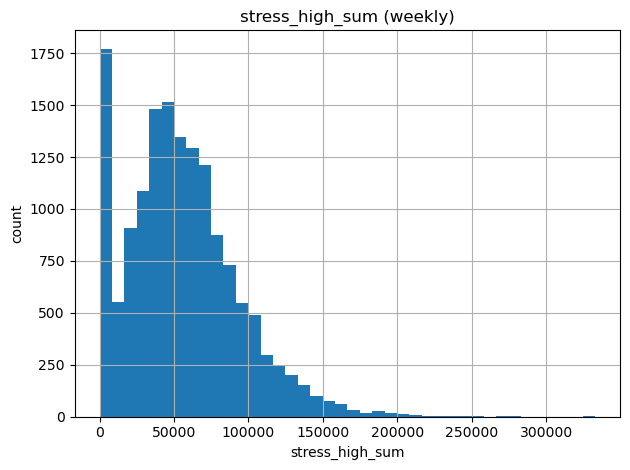

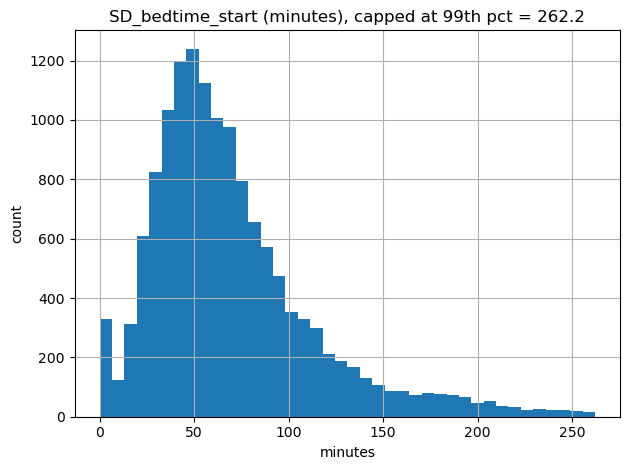

Sleep minutes cap (99th percentile): 262.21


In [196]:
#histograms
plt.figure()
stress_sleep["stress_high_sum"].dropna().hist(bins=40)
plt.title("stress_high_sum (weekly)")
plt.xlabel("stress_high_sum")
plt.ylabel("count")
plt.tight_layout()
plt.savefig(OUT_DIR / "hist_stress_high_sum.png", dpi=200)
plt.show()

sleep_min = stress_sleep["SD_bedtime_start_min"].dropna()
x_cap = sleep_min.quantile(0.99)

plt.figure()
sleep_min.hist(bins=40, range=(0, x_cap))
plt.title(f"SD_bedtime_start (minutes), capped at 99th pct = {x_cap:.1f}")
plt.xlabel("minutes")
plt.ylabel("count")
plt.tight_layout()
plt.savefig(OUT_DIR / "hist_SD_bedtime_start_min_capped.png", dpi=200)
plt.show()

print(f"Sleep minutes cap (99th percentile): {x_cap:.2f}")

In [197]:
#load and process cycle data
cycles_df = pd.read_csv(DOWNLOADS / "earlyfeb_finalweekliess.csv", low_memory=False)
if "id_num" in cycles_df.columns:
    cycles_df["id_num"] = cycles_df["id_num"].astype(str).str.strip()
cycles = cycles_df[["id_num", "menzie_start", "cycle length (days)"]].copy()
cycles["menzie_start"] = pd.to_datetime(cycles["menzie_start"], errors="coerce")
cycles = cycles.dropna(subset=["menzie_start", "cycle length (days)"])
cycles["cycle_length_days"] = pd.to_numeric(cycles["cycle length (days)"], errors="coerce")
cycles = cycles.dropna(subset=["cycle_length_days"])
cycles = cycles.sort_values(["id_num", "menzie_start"])

In [198]:
#calculate cycle regularity
cycle_reg = (
    cycles
    .groupby("id_num")["cycle_length_days"]
    .agg(
        mean_cycle_length="mean",
        sd_cycle_length="std",
        n_cycles="count"
    )
    .reset_index()
)
cycle_reg = cycle_reg[cycle_reg["n_cycles"] >= 3].copy()

# exclude lactating participants
lactating_ids = ["10406", "10308", "10361", "10413", "10364", "10487", "10375", "10506", "10505", "11011", "10380", "10409", "10395", "10365", "10390", "10449", "10624", "10373", "10491", "10625", "11014", "10600"]
cycle_reg = cycle_reg[~cycle_reg["id_num"].astype(str).isin(lactating_ids)].copy()

# ensure id_num is numeric for merges
cycle_reg["id_num"] = pd.to_numeric(cycle_reg["id_num"], errors="coerce")
cycle_reg = cycle_reg.dropna(subset=["id_num"])

print(f"Participants with 3+ cycles (excluding lactating): {len(cycle_reg)}")

Participants with 3+ cycles (excluding lactating): 229


In [199]:
# Descriptive statistics for cycle length
print(cycles["cycle_length_days"].describe())
print(f"\nTotal number of cycles: {len(cycles)}")
print(f"Number of unique participants: {cycles['id_num'].nunique()}")

count    2003.000000
mean       29.543684
std         8.271943
min        14.000000
25%        26.000000
50%        28.000000
75%        31.000000
max       177.000000
Name: cycle_length_days, dtype: float64

Total number of cycles: 2003
Number of unique participants: 301


In [200]:
#person-level stress
stress_person = (
    stress
    .groupby("name")["stress_high_sum"]
    .mean()
    .reset_index()
    .rename(columns={"name": "id_num", "stress_high_sum": "mean_total_stress_high"})
)
stress_person["id_num"] = pd.to_numeric(stress_person["id_num"], errors="coerce")


In [201]:
#load background data
background = pd.read_csv(DOWNLOADS / "backgrounddata.csv")
if "id_num" in background.columns:
    background["id_num"] = background["id_num"].astype(str).str.strip()
background["height"] = pd.to_numeric(background["height"], errors="coerce")
background["weight"] = pd.to_numeric(background["weight"], errors="coerce")
background["bmi"] = (background["weight"] / (background["height"]**2)) * 703

covars = background[["id_num", "years", "bmi"]].copy()
covars["id_num"] = pd.to_numeric(covars["id_num"], errors="coerce")
covars = covars.dropna(subset=["id_num"]).drop_duplicates(subset=["id_num"])


In [202]:
#load exercise data
exercise = pd.read_csv(DOWNLOADS / "exercise_weeklies_aug2024nov2025.csv")
if "name" in exercise.columns:
    exercise["name"] = exercise["name"].astype(str).str.strip()

exercise_person = (
    exercise
    .groupby("name")["active_calories"]
    .agg(mean_active_calories="mean", n_weeks_ex="count")
    .reset_index()
    .rename(columns={"name": "id_num"})
)

exercise_person["id_num"] = pd.to_numeric(exercise_person["id_num"], errors="coerce")

In [203]:
# Count unique id_num in each predictor file (stress, sleep, exercise)

# Stress file
stress_ids = pd.to_numeric(stress["name"], errors="coerce").dropna().nunique()
print(f"Stress file (stress_weeklies_aug2024nov2025.csv): {stress_ids} unique participants")

# Sleep file (merged into stress_sleep)
sleep_ids = pd.to_numeric(sleep["name"], errors="coerce").dropna().nunique()
print(f"Sleep file (sleepsd_weeklies_aug2024nov2025.csv): {sleep_ids} unique participants")

# Exercise file
exercise_ids = pd.to_numeric(exercise["name"], errors="coerce").dropna().nunique()
print(f"Exercise file (exercise_weeklies_aug2024nov2025.csv): {exercise_ids} unique participants")

# Also show how many have valid SD_bedtime_start_min after the merge
sleep_valid = stress_sleep.dropna(subset=["SD_bedtime_start_min"])
sleep_valid_ids = pd.to_numeric(sleep_valid["name"], errors="coerce").dropna().nunique()
print(f"\nParticipants with valid sleep SD (after merge): {sleep_valid_ids}")

# Background/covariates file
bg_ids = covars.dropna(subset=["id_num", "years", "bmi"])["id_num"].nunique()
print(f"Background file with valid age+BMI: {bg_ids} unique participants")

Stress file (stress_weeklies_aug2024nov2025.csv): 332 unique participants
Sleep file (sleepsd_weeklies_aug2024nov2025.csv): 330 unique participants
Exercise file (exercise_weeklies_aug2024nov2025.csv): 327 unique participants

Participants with valid sleep SD (after merge): 330
Background file with valid age+BMI: 276 unique participants


In [204]:
# merge for stress regression
df_reg = (
    cycle_reg
    .merge(stress_person, on="id_num", how="left")
    .merge(covars, on="id_num", how="left")
)
dfm = df_reg.dropna(subset=["sd_cycle_length", "mean_total_stress_high", "years", "bmi"]).copy()
print(f"Stress regression N: {len(dfm)}")

Stress regression N: 197


In [205]:
#z-score predictors
def zscore(s):
    return (s - s.mean()) / s.std(ddof=0)

dfm["stress_z"] = zscore(dfm["mean_total_stress_high"])
dfm["age_z"] = zscore(dfm["years"])
dfm["bmi_z"] = zscore(dfm["bmi"])

In [206]:
#stress regression
model_stress = smf.ols("sd_cycle_length ~ stress_z + age_z + bmi_z", data=dfm).fit()
print(model_stress.summary())

                            OLS Regression Results                            
Dep. Variable:        sd_cycle_length   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                 -0.009
Method:                 Least Squares   F-statistic:                    0.4352
Date:                Wed, 25 Feb 2026   Prob (F-statistic):              0.728
Time:                        10:27:44   Log-Likelihood:                -608.81
No. Observations:                 197   AIC:                             1226.
Df Residuals:                     193   BIC:                             1239.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      5.4794      0.383     14.309      0.0

In [207]:
#person-level sleep
sleep_person = (
    stress_sleep
    .groupby("name")["SD_bedtime_start_min"]
    .mean()
    .reset_index()
    .rename(columns={"name": "id_num", "SD_bedtime_start_min": "mean_sleepstart_sd_min"})
)
sleep_person["id_num"] = pd.to_numeric(sleep_person["id_num"], errors="coerce")


In [208]:
#merge for sleep regression
df_reg_sleep = (
    cycle_reg
    .merge(sleep_person, on="id_num", how="left")
    .merge(covars, on="id_num", how="left")
)
dfm_sleep = df_reg_sleep.dropna(subset=["sd_cycle_length", "mean_sleepstart_sd_min", "years", "bmi"]).copy()
print(f"Sleep regression N: {len(dfm_sleep)}")

dfm_sleep["sleep_z"] = zscore(dfm_sleep["mean_sleepstart_sd_min"])
dfm_sleep["age_z"] = zscore(dfm_sleep["years"])
dfm_sleep["bmi_z"] = zscore(dfm_sleep["bmi"])


Sleep regression N: 197


In [209]:
#sleep regression
model_sleep = smf.ols("sd_cycle_length ~ sleep_z + age_z + bmi_z", data=dfm_sleep).fit()
print(model_sleep.summary())

                            OLS Regression Results                            
Dep. Variable:        sd_cycle_length   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                 -0.007
Method:                 Least Squares   F-statistic:                    0.5465
Date:                Wed, 25 Feb 2026   Prob (F-statistic):              0.651
Time:                        10:27:44   Log-Likelihood:                -608.64
No. Observations:                 197   AIC:                             1225.
Df Residuals:                     193   BIC:                             1238.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      5.4794      0.383     14.321      0.0

In [210]:
#merge for exercise regression
df_reg_ex = (
    cycle_reg
    .merge(exercise_person, on="id_num", how="left")
    .merge(covars, on="id_num", how="left")
)
dfm_ex = df_reg_ex.dropna(subset=["sd_cycle_length", "mean_active_calories", "years", "bmi"]).copy()
print(f"Exercise regression N: {len(dfm_ex)}")

dfm_ex["exercise_z"] = zscore(dfm_ex["mean_active_calories"])
dfm_ex["age_z"] = zscore(dfm_ex["years"])
dfm_ex["bmi_z"] = zscore(dfm_ex["bmi"])

Exercise regression N: 197


In [211]:
# Get id_num sets from both dataframes
cycle_ids = set(cycle_reg["id_num"].dropna().unique())
stress_ids = set(stress_person["id_num"].dropna().unique())

# Find non-overlapping values
in_cycles_not_stress = cycle_ids - stress_ids
in_stress_not_cycles = stress_ids - cycle_ids
overlapping = cycle_ids & stress_ids

print(f"IDs in cycle_reg: {len(cycle_ids)}")
print(f"IDs in stress_person: {len(stress_ids)}")
print(f"Overlapping IDs: {len(overlapping)}")
print(f"\nIn cycle_reg but NOT in stress_person ({len(in_cycles_not_stress)}):")
print(sorted(in_cycles_not_stress))
print(f"\nIn stress_person but NOT in cycle_reg ({len(in_stress_not_cycles)}):")
print(sorted(in_stress_not_cycles))

# Show sample values from each to check formatting/type differences
print("\n--- Sample id_num values ---")
print(f"cycle_reg id_num dtype: {cycle_reg['id_num'].dtype}")
print(f"stress_person id_num dtype: {stress_person['id_num'].dtype}")
print(f"\ncycle_reg sample: {sorted(cycle_reg['id_num'].dropna().unique())[:10]}")
print(f"stress_person sample: {sorted(stress_person['id_num'].dropna().unique())[:10]}")

IDs in cycle_reg: 229
IDs in stress_person: 332
Overlapping IDs: 219

In cycle_reg but NOT in stress_person (10):
[np.int64(10199), np.int64(10204), np.int64(10214), np.int64(10216), np.int64(10247), np.int64(10253), np.int64(10260), np.int64(10276), np.int64(10404), np.int64(10452)]

In stress_person but NOT in cycle_reg (113):
[np.int64(10201), np.int64(10202), np.int64(10206), np.int64(10211), np.int64(10222), np.int64(10230), np.int64(10235), np.int64(10237), np.int64(10238), np.int64(10241), np.int64(10246), np.int64(10251), np.int64(10259), np.int64(10263), np.int64(10264), np.int64(10265), np.int64(10267), np.int64(10268), np.int64(10287), np.int64(10290), np.int64(10305), np.int64(10308), np.int64(10316), np.int64(10317), np.int64(10318), np.int64(10326), np.int64(10337), np.int64(10340), np.int64(10348), np.int64(10352), np.int64(10355), np.int64(10358), np.int64(10361), np.int64(10364), np.int64(10365), np.int64(10366), np.int64(10368), np.int64(10372), np.int64(10373), np.in

In [212]:
#exercise regression
model_exercise = smf.ols("sd_cycle_length ~ exercise_z + age_z + bmi_z", data=dfm_ex).fit()
print(model_exercise.summary())

                            OLS Regression Results                            
Dep. Variable:        sd_cycle_length   R-squared:                       0.010
Model:                            OLS   Adj. R-squared:                 -0.006
Method:                 Least Squares   F-statistic:                    0.6387
Date:                Wed, 25 Feb 2026   Prob (F-statistic):              0.591
Time:                        10:27:44   Log-Likelihood:                -608.50
No. Observations:                 197   AIC:                             1225.
Df Residuals:                     193   BIC:                             1238.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      5.4794      0.382     14.331      0.0

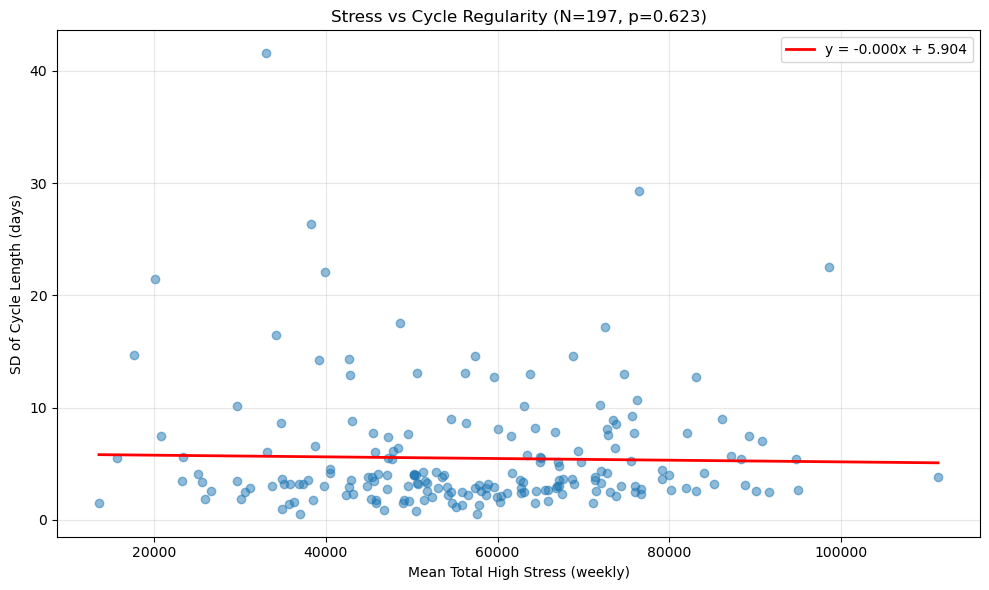

Correlation: -0.025


In [213]:
# Plotting block 1: Stress vs Cycle Regularity
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 6))
plt.scatter(dfm["mean_total_stress_high"], dfm["sd_cycle_length"], alpha=0.5)

# Add regression line
x_stress = dfm["mean_total_stress_high"]
y_stress = dfm["sd_cycle_length"]
z = np.polyfit(x_stress, y_stress, 1)
p = np.poly1d(z)
x_line = np.linspace(x_stress.min(), x_stress.max(), 100)
plt.plot(x_line, p(x_line), "r-", linewidth=2, label=f'y = {z[0]:.3f}x + {z[1]:.3f}')

plt.xlabel("Mean Total High Stress (weekly)")
plt.ylabel("SD of Cycle Length (days)")
plt.title(f"Stress vs Cycle Regularity (N={len(dfm)}, p={model_stress.pvalues['stress_z']:.3f})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / "regression_stress_vs_cycle.png", dpi=200)
plt.show()

print(f"Correlation: {x_stress.corr(y_stress):.3f}")

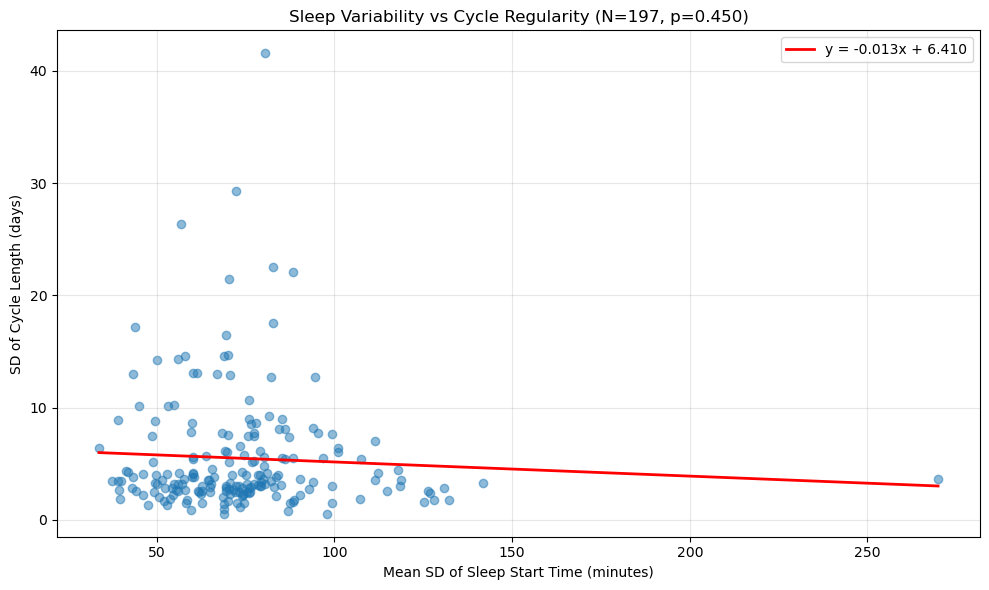

Correlation: -0.059


In [214]:
# Plotting block 2: Sleep Variability vs Cycle Regularity
plt.figure(figsize=(10, 6))
plt.scatter(dfm_sleep["mean_sleepstart_sd_min"], dfm_sleep["sd_cycle_length"], alpha=0.5)

# Add regression line
x_sleep = dfm_sleep["mean_sleepstart_sd_min"]
y_sleep = dfm_sleep["sd_cycle_length"]
z = np.polyfit(x_sleep, y_sleep, 1)
p = np.poly1d(z)
x_line = np.linspace(x_sleep.min(), x_sleep.max(), 100)
plt.plot(x_line, p(x_line), "r-", linewidth=2, label=f'y = {z[0]:.3f}x + {z[1]:.3f}')

plt.xlabel("Mean SD of Sleep Start Time (minutes)")
plt.ylabel("SD of Cycle Length (days)")
plt.title(f"Sleep Variability vs Cycle Regularity (N={len(dfm_sleep)}, p={model_sleep.pvalues['sleep_z']:.3f})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / "regression_sleep_vs_cycle.png", dpi=200)
plt.show()

print(f"Correlation: {x_sleep.corr(y_sleep):.3f}")

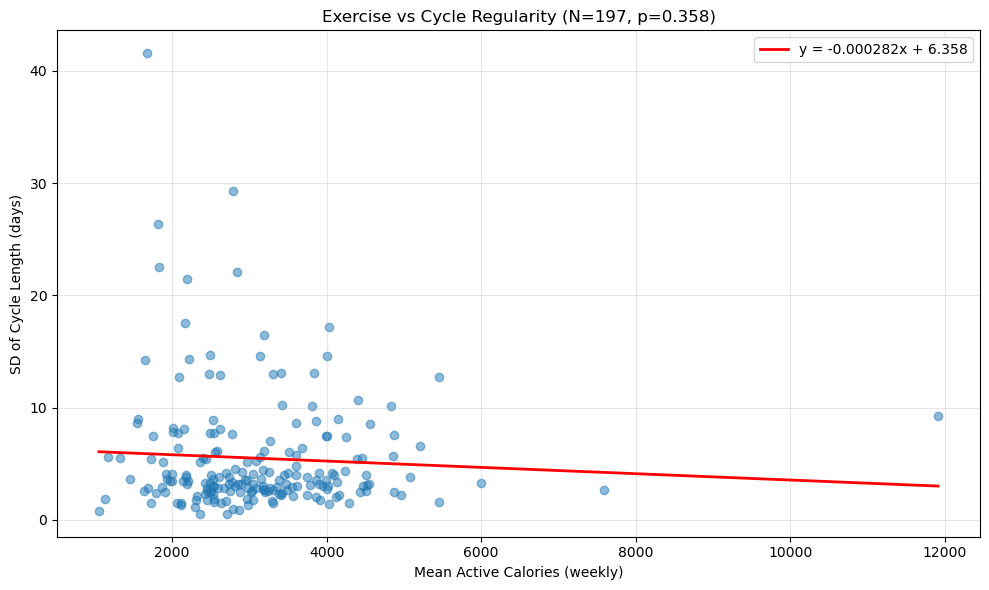

Correlation: -0.062


In [215]:
# Plotting block 3: Exercise vs Cycle Regularity
plt.figure(figsize=(10, 6))
plt.scatter(dfm_ex["mean_active_calories"], dfm_ex["sd_cycle_length"], alpha=0.5)

# Add regression line
x_exercise = dfm_ex["mean_active_calories"]
y_exercise = dfm_ex["sd_cycle_length"]
z = np.polyfit(x_exercise, y_exercise, 1)
p = np.poly1d(z)
x_line = np.linspace(x_exercise.min(), x_exercise.max(), 100)
plt.plot(x_line, p(x_line), "r-", linewidth=2, label=f'y = {z[0]:.6f}x + {z[1]:.3f}')

plt.xlabel("Mean Active Calories (weekly)")
plt.ylabel("SD of Cycle Length (days)")
plt.title(f"Exercise vs Cycle Regularity (N={len(dfm_ex)}, p={model_exercise.pvalues['exercise_z']:.3f})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / "regression_exercise_vs_cycle.png", dpi=200)
plt.show()

print(f"Correlation: {x_exercise.corr(y_exercise):.3f}")

In [216]:
# COHORTS analysis
cohort_files = {
    "pill": "pill_weekliesaug2024-jan2026.csv",
    "perimenopause": "perimenopause_weekliesaug2024-jan2026.csv",
    "healthy_naturally_cycling": "healthy_nc_weekliesaug2024-jan2026.csv",
    "endometriosis": "endo_weekliesaug2024-jan2026.csv",
    "copper_iud": "copperIUD_weekliesaug2024-jan2026.csv",
    "hormonal_iud": "hormonalIUD_weekliesaug2024-jan2026.csv",
    "pcos": "pcsos_weekliesaug2024-jan2026.csv",
    "fibroids": "fibroids_weekliesaug2024-jan2026.csv",
}

# Load all cohort files and compute cycle regularity per cohort
cohort_data = {}  # raw cycle data per cohort
cohort_cycle_regs = {}  # cycle regularity (mean, sd, n) per cohort

for cohort_name, filepath in cohort_files.items():
    try:
        df = pd.read_csv(filepath, low_memory=False)
    except FileNotFoundError:
        print(f"WARNING: File not found for cohort '{cohort_name}': {filepath}")
        continue

    # Standardize columns
    temp = df[["id_num", "menzie_start", "cycle length (days)"]].copy()
    temp["menzie_start"] = pd.to_datetime(temp["menzie_start"], errors="coerce")
    temp["cycle_length_days"] = pd.to_numeric(temp["cycle length (days)"], errors="coerce")
    temp = temp.dropna(subset=["menzie_start", "cycle_length_days"])
    temp["id_num"] = pd.to_numeric(temp["id_num"], errors="coerce")
    temp = temp.dropna(subset=["id_num"])
    temp = temp.sort_values(["id_num", "menzie_start"])

    cohort_data[cohort_name] = temp

    # Calculate per-person cycle regularity
    reg = (
        temp
        .groupby("id_num")["cycle_length_days"]
        .agg(
            mean_cycle_length="mean",
            sd_cycle_length="std",
            n_cycles="count"
        )
        .reset_index()
    )
    reg = reg[reg["n_cycles"] >= 3].copy()
    cohort_cycle_regs[cohort_name] = reg

    print(f"Cohort '{cohort_name}': {len(temp)} cycles, "
          f"{temp['id_num'].nunique()} participants, "
          f"{len(reg)} with 3+ cycles")

Cohort 'pill': 230 cycles, 26 participants, 26 with 3+ cycles
Cohort 'perimenopause': 3 cycles, 1 participants, 1 with 3+ cycles
Cohort 'healthy_naturally_cycling': 724 cycles, 91 participants, 91 with 3+ cycles
Cohort 'endometriosis': 37 cycles, 5 participants, 5 with 3+ cycles
Cohort 'copper_iud': 54 cycles, 7 participants, 7 with 3+ cycles
Cohort 'hormonal_iud': 91 cycles, 11 participants, 11 with 3+ cycles
Cohort 'pcos': 95 cycles, 12 participants, 12 with 3+ cycles
Cohort 'fibroids': 104 cycles, 12 participants, 12 with 3+ cycles


In [217]:
# Descriptive statistics for "cycle length (days)" per cohort
for cohort_name, df in cohort_data.items():
    print("=" * 60)
    print(f"Cohort: {cohort_name}")
    print("-" * 60)
    print(df["cycle_length_days"].describe())
    print(f"Total cycles: {len(df)}")
    print(f"Unique participants: {df['id_num'].nunique()}")
    print()

Cohort: pill
------------------------------------------------------------
count    230.000000
mean      29.265217
std       10.689509
min        5.000000
25%       25.000000
50%       28.000000
75%       31.000000
max       80.000000
Name: cycle_length_days, dtype: float64
Total cycles: 230
Unique participants: 26

Cohort: perimenopause
------------------------------------------------------------
count     3.000000
mean     24.666667
std      16.563011
min       9.000000
25%      16.000000
50%      23.000000
75%      32.500000
max      42.000000
Name: cycle_length_days, dtype: float64
Total cycles: 3
Unique participants: 1

Cohort: healthy_naturally_cycling
------------------------------------------------------------
count    724.000000
mean      29.756906
std        9.825533
min        5.000000
25%       26.000000
50%       29.000000
75%       31.000000
max      115.000000
Name: cycle_length_days, dtype: float64
Total cycles: 724
Unique participants: 91

Cohort: endometriosis
--------

In [218]:
# Three regressions for each cohort
all_results = {}

for cohort_name, cycle_reg_df in cohort_cycle_regs.items():
    print("=" * 70)
    print(f"COHORT: {cohort_name.upper()}")
    print("=" * 70)

    results = {}

    # stress regression
    df_stress = (
        cycle_reg_df
        .merge(stress_person, on="id_num", how="left")
        .merge(covars, on="id_num", how="left")
    )
    dfm_stress = df_stress.dropna(
        subset=["sd_cycle_length", "mean_total_stress_high", "years", "bmi"]
    ).copy()

    if len(dfm_stress) >= 5:
        dfm_stress["stress_z"] = zscore(dfm_stress["mean_total_stress_high"])
        dfm_stress["age_z"] = zscore(dfm_stress["years"])
        dfm_stress["bmi_z"] = zscore(dfm_stress["bmi"])
        model_s = smf.ols("sd_cycle_length ~ stress_z + age_z + bmi_z",
                          data=dfm_stress).fit()
        results["stress"] = {
            "model": model_s, "data": dfm_stress, "n": len(dfm_stress)
        }
        print(f"\n--- Stress Regression (N={len(dfm_stress)}) ---")
        print(model_s.summary())
    else:
        print(f"\n--- Stress Regression: SKIPPED (N={len(dfm_stress)} < 10) ---")

    # sleep regression
    df_sleep = (
        cycle_reg_df
        .merge(sleep_person, on="id_num", how="left")
        .merge(covars, on="id_num", how="left")
    )
    dfm_sleep_c = df_sleep.dropna(
        subset=["sd_cycle_length", "mean_sleepstart_sd_min", "years", "bmi"]
    ).copy()

    if len(dfm_sleep_c) >= 5:
        dfm_sleep_c["sleep_z"] = zscore(dfm_sleep_c["mean_sleepstart_sd_min"])
        dfm_sleep_c["age_z"] = zscore(dfm_sleep_c["years"])
        dfm_sleep_c["bmi_z"] = zscore(dfm_sleep_c["bmi"])
        model_sl = smf.ols("sd_cycle_length ~ sleep_z + age_z + bmi_z",
                           data=dfm_sleep_c).fit()
        results["sleep"] = {
            "model": model_sl, "data": dfm_sleep_c, "n": len(dfm_sleep_c)
        }
        print(f"\n--- Sleep Regression (N={len(dfm_sleep_c)}) ---")
        print(model_sl.summary())
    else:
        print(f"\n--- Sleep Regression: SKIPPED (N={len(dfm_sleep_c)} < 10) ---")

    # exercise regression
    df_ex = (
        cycle_reg_df
        .merge(exercise_person, on="id_num", how="left")
        .merge(covars, on="id_num", how="left")
    )
    dfm_ex_c = df_ex.dropna(
        subset=["sd_cycle_length", "mean_active_calories", "years", "bmi"]
    ).copy()

    if len(dfm_ex_c) >= 5:
        dfm_ex_c["exercise_z"] = zscore(dfm_ex_c["mean_active_calories"])
        dfm_ex_c["age_z"] = zscore(dfm_ex_c["years"])
        dfm_ex_c["bmi_z"] = zscore(dfm_ex_c["bmi"])
        model_ex = smf.ols("sd_cycle_length ~ exercise_z + age_z + bmi_z",
                           data=dfm_ex_c).fit()
        results["exercise"] = {
            "model": model_ex, "data": dfm_ex_c, "n": len(dfm_ex_c)
        }
        print(f"\n--- Exercise Regression (N={len(dfm_ex_c)}) ---")
        print(model_ex.summary())
    else:
        print(f"\n--- Exercise Regression: SKIPPED (N={len(dfm_ex_c)} < 10) ---")

    all_results[cohort_name] = results
    print("\n")

COHORT: PILL

--- Stress Regression (N=26) ---
                            OLS Regression Results                            
Dep. Variable:        sd_cycle_length   R-squared:                       0.065
Model:                            OLS   Adj. R-squared:                 -0.063
Method:                 Least Squares   F-statistic:                    0.5066
Date:                Wed, 25 Feb 2026   Prob (F-statistic):              0.682
Time:                        10:27:44   Log-Likelihood:                -81.088
No. Observations:                  26   AIC:                             170.2
Df Residuals:                      22   BIC:                             175.2
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Inter

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 5 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 5 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 5 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 7 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "
/opt/anaconda3/lib/pytho

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 5 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 5 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 5 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 7 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "
/opt/anaconda3/lib/pytho

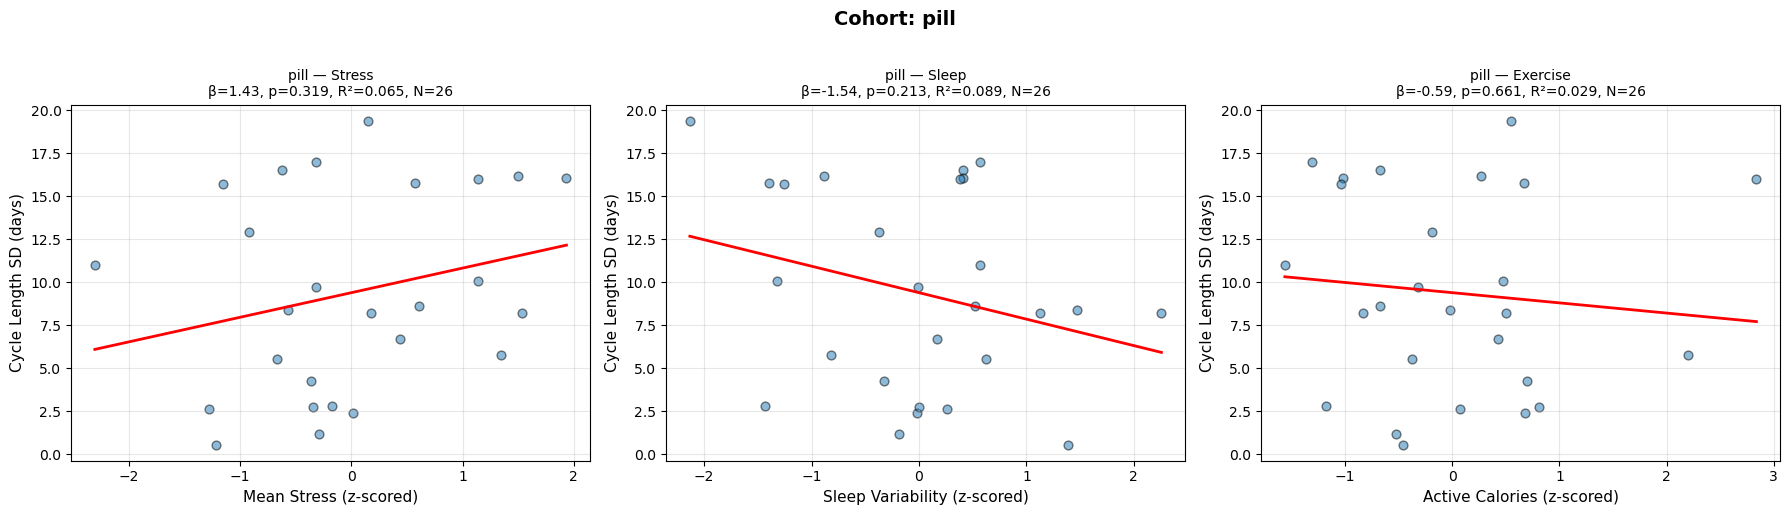

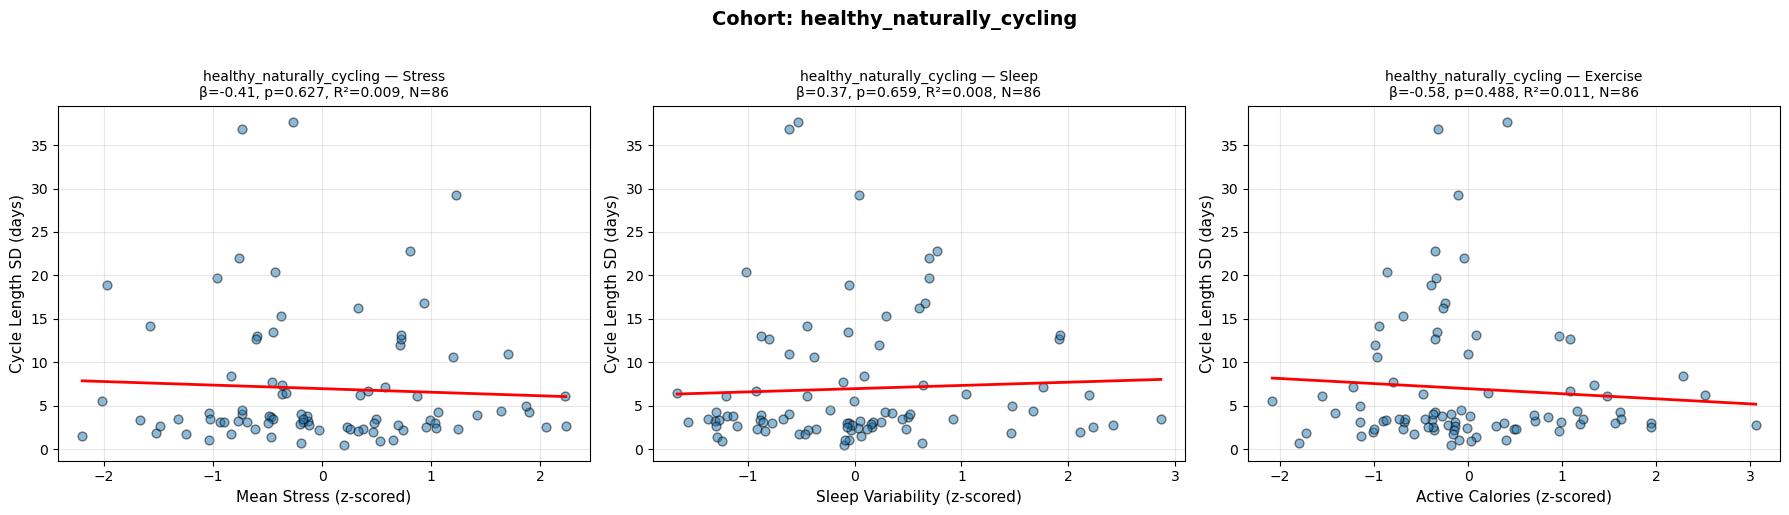

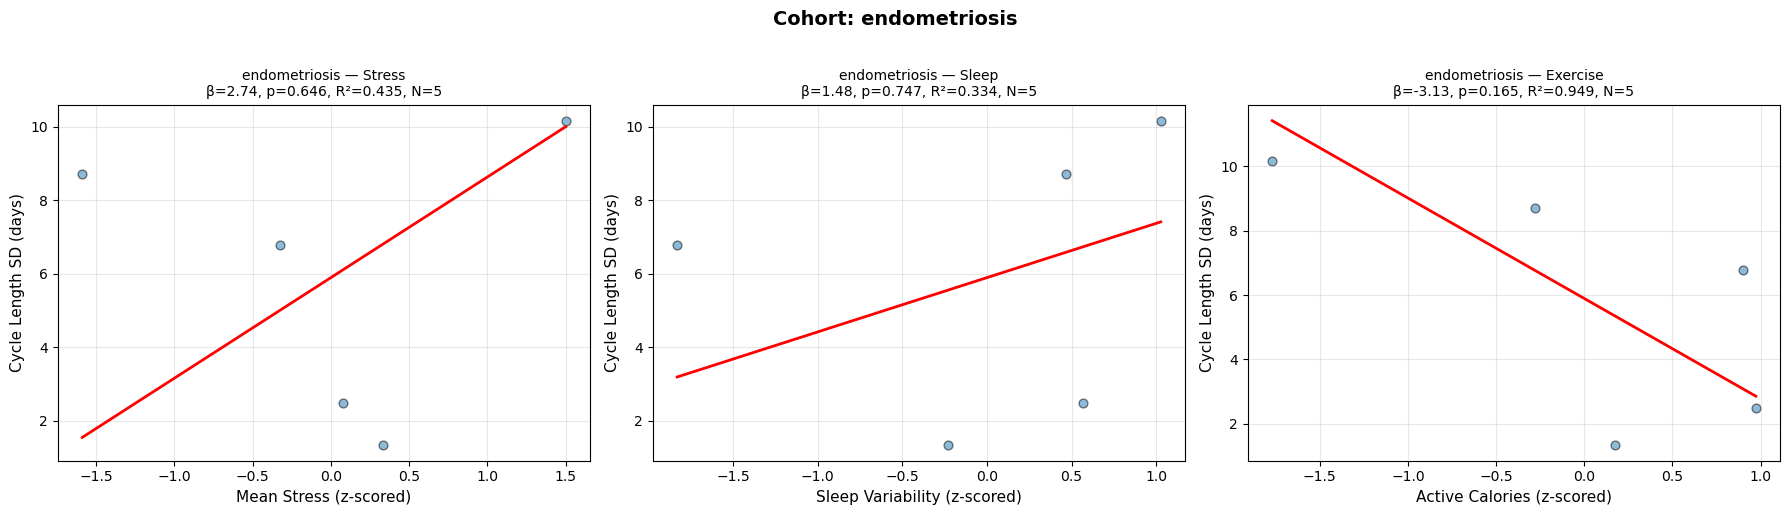

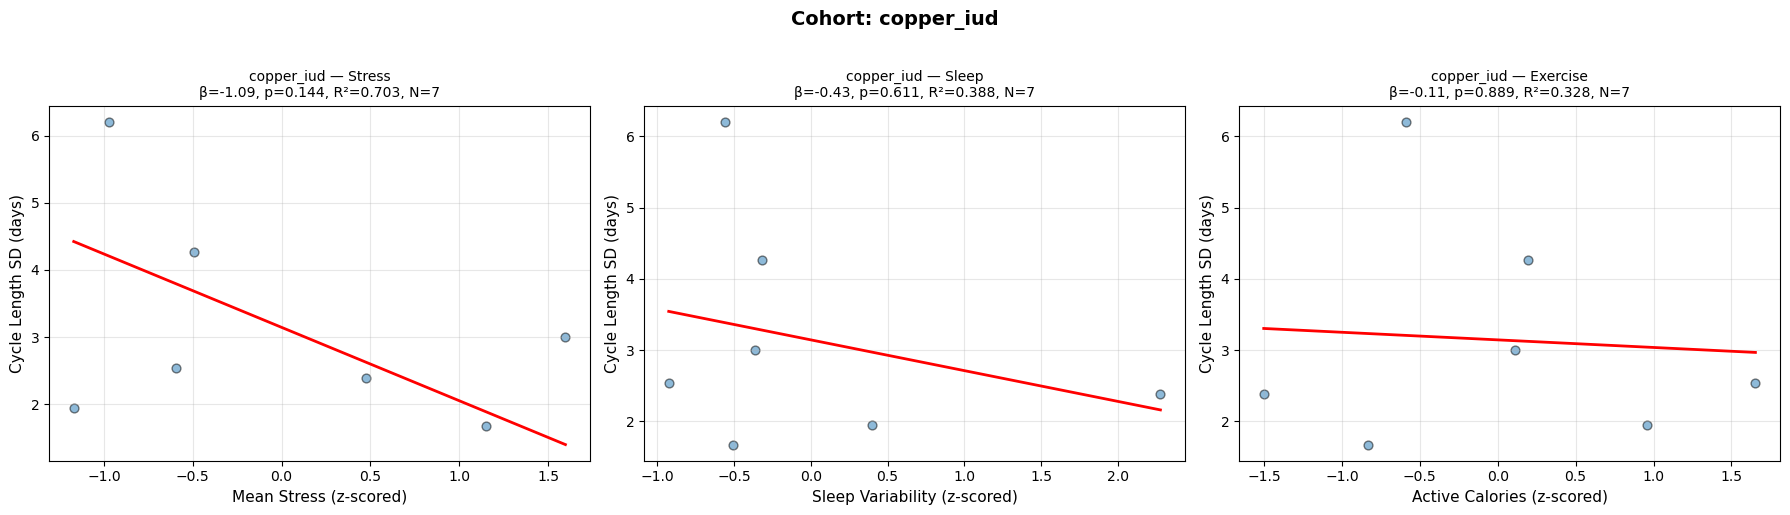

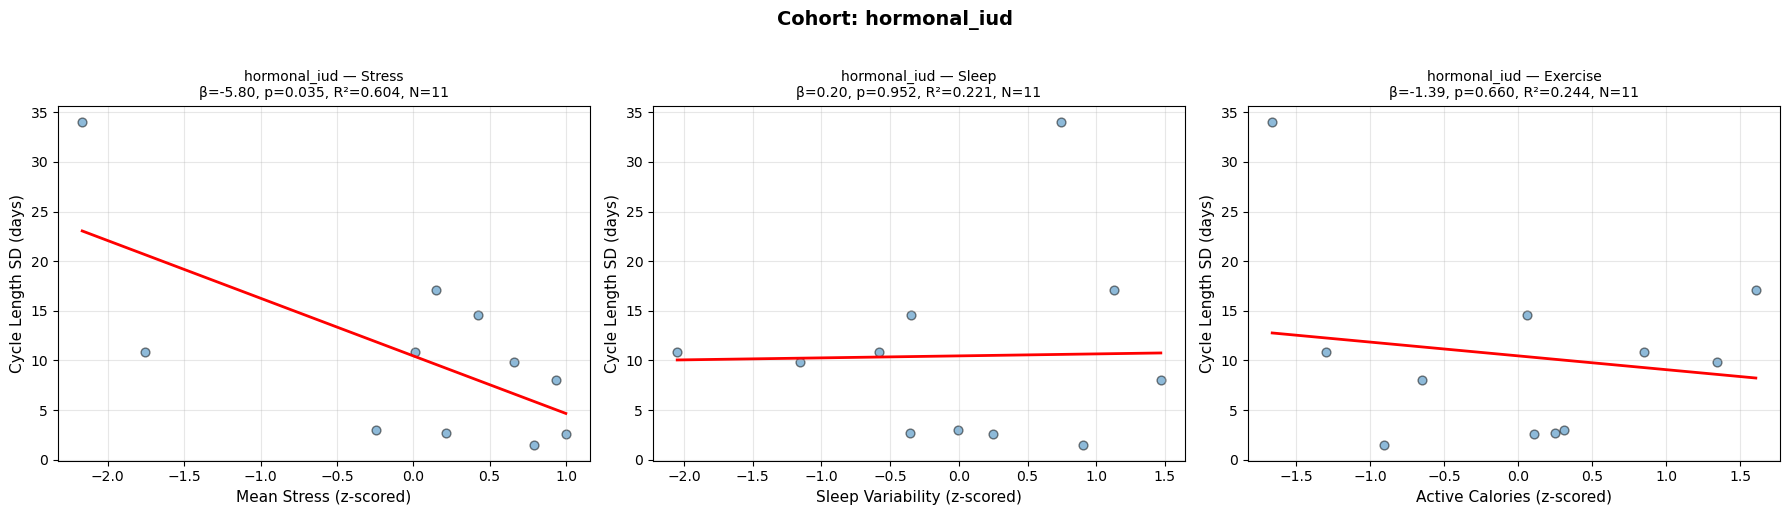

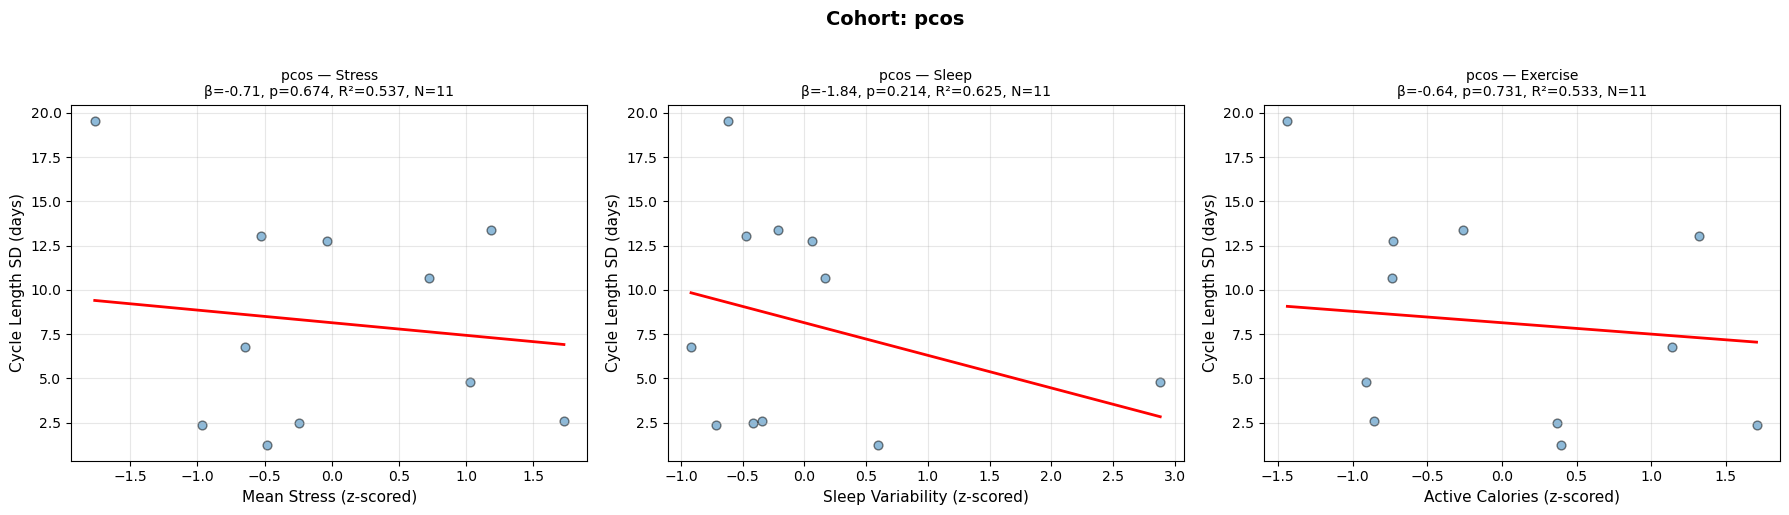

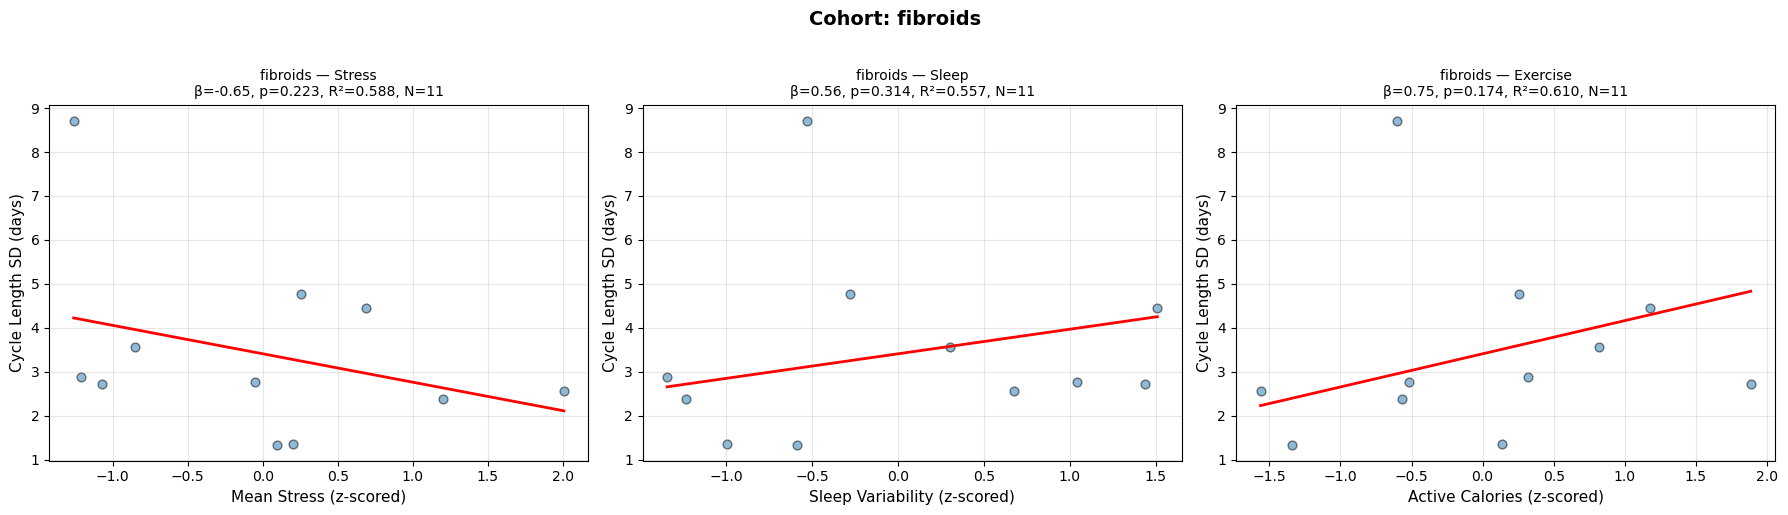

In [219]:
# Plot the three regressions for each cohort
predictor_map = {
    "stress": ("stress_z", "Mean Stress (z-scored)"),
    "sleep": ("sleep_z", "Sleep Variability (z-scored)"),
    "exercise": ("exercise_z", "Active Calories (z-scored)"),
}

for cohort_name, results in all_results.items():
    n_models = len(results)
    if n_models == 0:
        continue

    fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 5))
    if n_models == 1:
        axes = [axes]

    for ax, (reg_type, info) in zip(axes, results.items()):
        model = info["model"]
        data = info["data"]
        n = info["n"]
        x_col, x_label = predictor_map[reg_type]
        y_col = "sd_cycle_length"

        coef = model.params[x_col]
        pval = model.pvalues[x_col]
        r2 = model.rsquared

        ax.scatter(data[x_col], data[y_col], alpha=0.5, edgecolors="k", s=40)

        # Regression line (partial effect shown as simple line for visualization)
        import numpy as np
        x_range = np.linspace(data[x_col].min(), data[x_col].max(), 100)
        y_pred = model.params["Intercept"] + coef * x_range
        ax.plot(x_range, y_pred, color="red", linewidth=2)

        ax.set_xlabel(x_label, fontsize=11)
        ax.set_ylabel("Cycle Length SD (days)", fontsize=11)
        ax.set_title(
            f"{cohort_name} — {reg_type.capitalize()}\n"
            f"β={coef:.2f}, p={pval:.3f}, R²={r2:.3f}, N={n}",
            fontsize=10
        )
        ax.grid(True, alpha=0.3)

    fig.suptitle(f"Cohort: {cohort_name}", fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig(OUT_DIR / f"regression_plots_{cohort_name}.png", dpi=200,
                bbox_inches="tight")
    plt.show()

In [220]:
# Load person-level sleep average/SD data
sleepavg = pd.read_csv(DOWNLOADS / "sleepavg_aug2024jan2026.csv")
sleepavg = sleepavg.rename(columns={"name": "id_num"})
sleepavg["id_num"] = pd.to_numeric(sleepavg["id_num"], errors="coerce")

# Convert Average_Sleep and Sleep_StdDev from seconds to hours for interpretability
sleepavg["avg_sleep_hrs"] = sleepavg["Average_Sleep"] / 3600
sleepavg["sleep_sd_hrs"] = sleepavg["Sleep_StdDev"] / 3600

print(sleepavg[["avg_sleep_hrs", "sleep_sd_hrs"]].describe())
sleepavg.head()

       avg_sleep_hrs  sleep_sd_hrs
count     331.000000    330.000000
mean        7.066458      1.696371
std         0.762299      0.539255
min         2.041667      0.626608
25%         6.653178      1.336977
50%         7.092785      1.610012
75%         7.490856      1.957740
max        10.951234      4.469988


,id_num,Average_Sleep,Sleep_StdDev,avg_sleep_hrs,sleep_sd_hrs
0,10200,28750.272374,3447.699394,7.986187,0.957694
1,10201,25666.530612,9024.746925,7.129592,2.506874
2,10202,26289.556787,7072.670706,7.302655,1.964631
3,10203,24450.172414,4100.518783,6.791715,1.139033
4,10205,27609.527897,4916.811122,7.669313,1.365781


In [221]:
# Merge cycle regularity with sleep avg/SD
cycle_sleep = cycle_reg.merge(sleepavg[["id_num", "avg_sleep_hrs", "sleep_sd_hrs"]],
                              on="id_num", how="inner")
print(f"Participants with cycle + sleep avg data: {len(cycle_sleep)}")
cycle_sleep.head()

Participants with cycle + sleep avg data: 219


,id_num,mean_cycle_length,sd_cycle_length,n_cycles,avg_sleep_hrs,sleep_sd_hrs
0,10200,24.052632,1.840099,19,7.986187,0.957694
1,10203,34.200000,17.164563,10,6.791715,1.139033
2,10205,32.200000,4.263541,10,7.669313,1.365781
3,10207,27.250000,5.545268,12,6.112047,1.789070
4,10208,28.615385,4.093459,13,8.258107,0.626608


In [222]:
# Regression: sd_cycle_length sleep_sd_hrs 
model_sleep_sd = smf.ols("sd_cycle_length ~ sleep_sd_hrs", data=cycle_sleep).fit()
print(model_sleep_sd.summary())

                            OLS Regression Results                            
Dep. Variable:        sd_cycle_length   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     1.455
Date:                Wed, 25 Feb 2026   Prob (F-statistic):              0.229
Time:                        10:27:47   Log-Likelihood:                -674.49
No. Observations:                 219   AIC:                             1353.
Df Residuals:                     217   BIC:                             1360.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        3.8882      1.245      3.123   

In [223]:
# Regression: sd_cycle_length  avg_sleep_hrs
model_avg_sleep = smf.ols("sd_cycle_length ~ avg_sleep_hrs", data=cycle_sleep).fit()
print(model_avg_sleep.summary())

                            OLS Regression Results                            
Dep. Variable:        sd_cycle_length   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.003
Method:                 Least Squares   F-statistic:                    0.2957
Date:                Wed, 25 Feb 2026   Prob (F-statistic):              0.587
Time:                        10:27:47   Log-Likelihood:                -675.07
No. Observations:                 219   AIC:                             1354.
Df Residuals:                     217   BIC:                             1361.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         3.3673      3.622      0.930

In [224]:
# Load weekly sleep-RHR regularity data 
sleeprhr = pd.read_csv(DOWNLOADS / "sleeprhr_weeklies_aug2024jan2026.csv")
sleeprhr[["week_start", "week_end"]] = sleeprhr["date_range"].str.split(" to ", expand=True)
sleeprhr["week_start"] = pd.to_datetime(sleeprhr["week_start"])
sleeprhr["week_end"] = pd.to_datetime(sleeprhr["week_end"])

# Person-level mean of within_four_hours_count
sleeprhr_person = (
    sleeprhr
    .groupby("name")["within_four_hours_count"]
    .mean()
    .reset_index()
    .rename(columns={"name": "id_num",
                      "within_four_hours_count": "mean_within_4hr_count"})
)
sleeprhr_person["id_num"] = pd.to_numeric(sleeprhr_person["id_num"], errors="coerce")

print(sleeprhr_person["mean_within_4hr_count"].describe())
sleeprhr_person.head()

count    84.000000
mean      2.399990
std       1.002588
min       0.000000
25%       1.682094
50%       2.239799
75%       2.973684
max       5.159091
Name: mean_within_4hr_count, dtype: float64


,id_num,mean_within_4hr_count
0,10199.0,2.590909
1,10201.0,1.685714
2,10202.0,0.781250
3,10203.0,3.418919
4,10204.0,2.054054


In [225]:
# Load daily sleep_hr data and compute person-level HRV SD 

sleep_hr = pd.read_csv(DOWNLOADS / "sleep_hr.csv", low_memory=False)

id_col = "name"

if id_col is not None:
    sleep_hr = sleep_hr.rename(columns={id_col: "id_num"})
    sleep_hr["id_num"] = pd.to_numeric(sleep_hr["id_num"], errors="coerce")
    sleep_hr["average_hrv"] = pd.to_numeric(sleep_hr["average_hrv"], errors="coerce")
    sleep_hr["average_heart_rate"] = pd.to_numeric(sleep_hr["average_heart_rate"], errors="coerce")
    sleep_hr["total_sleep_duration"] = pd.to_numeric(sleep_hr["total_sleep_duration"], errors="coerce")

    # Person-level: mean and SD of HRV, mean resting HR, mean sleep duration
    sleep_hr_person = (
        sleep_hr
        .groupby("id_num")
        .agg(
            mean_hrv=("average_hrv", "mean"),
            sd_hrv=("average_hrv", "std"),
            mean_rhr=("average_heart_rate", "mean"),
            mean_sleep_dur=("total_sleep_duration", "mean"),
            sd_sleep_dur=("total_sleep_duration", "std"),
        )
        .reset_index()
    )
    # Convert sleep duration from seconds to hours
    sleep_hr_person["mean_sleep_dur_hrs"] = sleep_hr_person["mean_sleep_dur"] / 3600
    sleep_hr_person["sd_sleep_dur_hrs"] = sleep_hr_person["sd_sleep_dur"] / 3600

    print(sleep_hr_person.describe())
else:
    print("⚠️  No participant ID column found in sleep_hr.csv. "
          "Available columns:", sleep_hr.columns.tolist())

             id_num    mean_hrv     sd_hrv   mean_rhr  mean_sleep_dur  \
count     81.000000   81.000000  81.000000  81.000000       81.000000   
mean   10367.061728   46.672275  12.470232  66.865629    25011.146637   
std      272.415737   22.577482   7.347950   7.837760     1697.290177   
min    10199.000000   16.553699   3.594558  45.868421    20604.920128   
25%    10223.000000   27.744780   6.669387  60.430726    23941.696113   
50%    10264.000000   41.400000  10.955680  66.939531    25192.071429   
75%    10290.000000   62.209150  15.459272  73.230030    26333.411765   
max    11014.000000  102.475325  45.948564  82.887500    29652.760736   

       sd_sleep_dur  mean_sleep_dur_hrs  sd_sleep_dur_hrs  
count     81.000000           81.000000         81.000000  
mean    4472.401498            6.947541          1.242334  
std     1090.018889            0.471469          0.302783  
min     2104.901699            5.723589          0.584695  
25%     3707.949806            6.650471   

In [226]:
# Merge cycle regularity with daily sleep HR metrics 
if id_col is not None:
    cycle_hr = cycle_reg.merge(sleep_hr_person, on="id_num", how="inner")
    print(f"Participants with cycle + sleep_hr data: {len(cycle_hr)}")
    display(cycle_hr.head())

Participants with cycle + sleep_hr data: 64


,id_num,mean_cycle_length,sd_cycle_length,n_cycles,mean_hrv,sd_hrv,mean_rhr,mean_sleep_dur,sd_sleep_dur,mean_sleep_dur_hrs,sd_sleep_dur_hrs
0,10199,29.250000,2.362908,4,41.400000,13.513602,71.612500,24049.000000,6918.092198,6.680278,1.921692
1,10203,34.200000,17.164563,10,68.616803,9.285716,57.141137,24635.901639,3301.981610,6.843306,0.917217
2,10204,30.818182,2.638870,11,44.562628,14.185560,71.890144,24527.618070,4538.964240,6.813227,1.260823
3,10205,32.200000,4.263541,10,86.208243,24.871584,55.199024,27275.726681,4055.009270,7.576591,1.126391
4,10207,27.250000,5.545268,12,29.235732,7.633490,60.776985,22236.774194,5045.288282,6.176882,1.401469


In [227]:
# Regression: sd_cycle_length  sd_hrv 
if id_col is not None and len(cycle_hr.dropna(subset=["sd_hrv", "sd_cycle_length"])) > 5:
    model_hrv = smf.ols("sd_cycle_length ~ sd_hrv", data=cycle_hr).fit()
    print(model_hrv.summary())

                            OLS Regression Results                            
Dep. Variable:        sd_cycle_length   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.016
Method:                 Least Squares   F-statistic:                  0.007340
Date:                Wed, 25 Feb 2026   Prob (F-statistic):              0.932
Time:                        10:27:48   Log-Likelihood:                -207.81
No. Observations:                  64   AIC:                             419.6
Df Residuals:                      62   BIC:                             423.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      6.1282      1.520      4.032      0.0

In [228]:
# Regression: sd_cycle_length  mean_rhr 
if id_col is not None and len(cycle_hr.dropna(subset=["mean_rhr", "sd_cycle_length"])) > 5:
    model_mean_rhr = smf.ols("sd_cycle_length ~ mean_rhr", data=cycle_hr).fit()
    print(model_mean_rhr.summary())

                            OLS Regression Results                            
Dep. Variable:        sd_cycle_length   R-squared:                       0.039
Model:                            OLS   Adj. R-squared:                  0.024
Method:                 Least Squares   F-statistic:                     2.535
Date:                Wed, 25 Feb 2026   Prob (F-statistic):              0.116
Time:                        10:27:48   Log-Likelihood:                -206.54
No. Observations:                  64   AIC:                             417.1
Df Residuals:                      62   BIC:                             421.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     17.2369      7.090      2.431      0.0

In [229]:
# Regression: sd_cycle_length  sd_sleep_dur_hrs 
if id_col is not None and len(cycle_hr.dropna(subset=["sd_sleep_dur_hrs", "sd_cycle_length"])) > 5:
    model_sleep_dur_sd = smf.ols("sd_cycle_length ~ sd_sleep_dur_hrs", data=cycle_hr).fit()
    print(model_sleep_dur_sd.summary())

                            OLS Regression Results                            
Dep. Variable:        sd_cycle_length   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.015
Method:                 Least Squares   F-statistic:                   0.03895
Date:                Wed, 25 Feb 2026   Prob (F-statistic):              0.844
Time:                        10:27:48   Log-Likelihood:                -207.80
No. Observations:                  64   AIC:                             419.6
Df Residuals:                      62   BIC:                             423.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            6.6583      3.344  

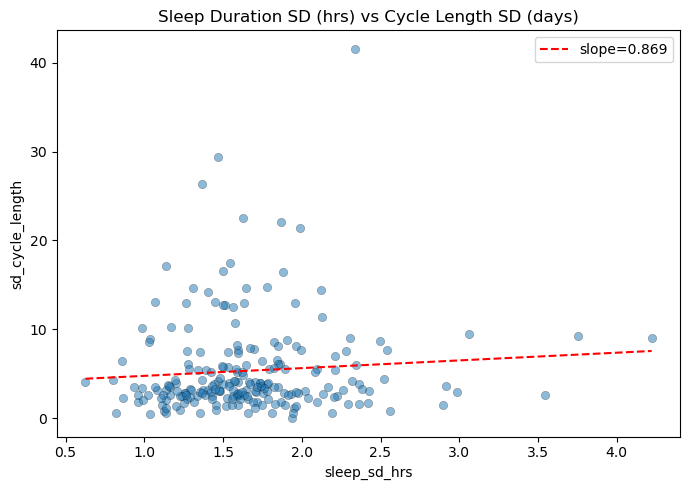

Saved: scatter_sleep_sd_hrs_vs_sd_cycle_length.png


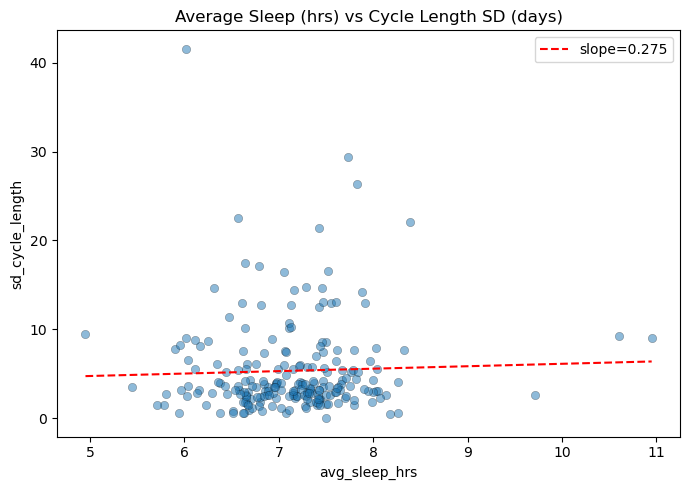

Saved: scatter_avg_sleep_hrs_vs_sd_cycle_length.png


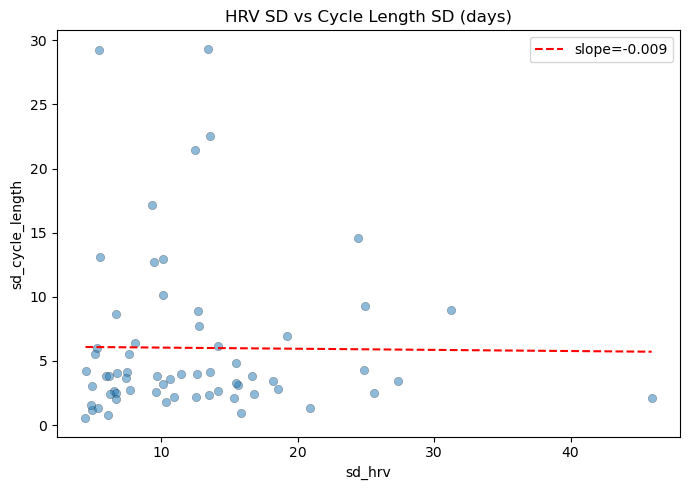

Saved: scatter_sd_hrv_vs_sd_cycle_length.png


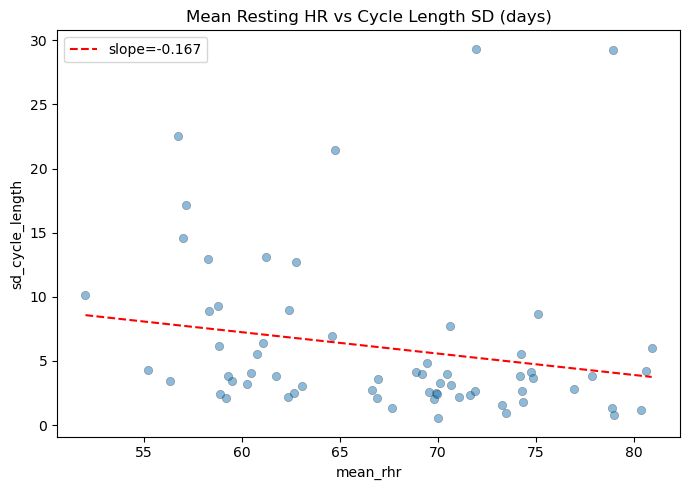

Saved: scatter_mean_rhr_vs_sd_cycle_length.png


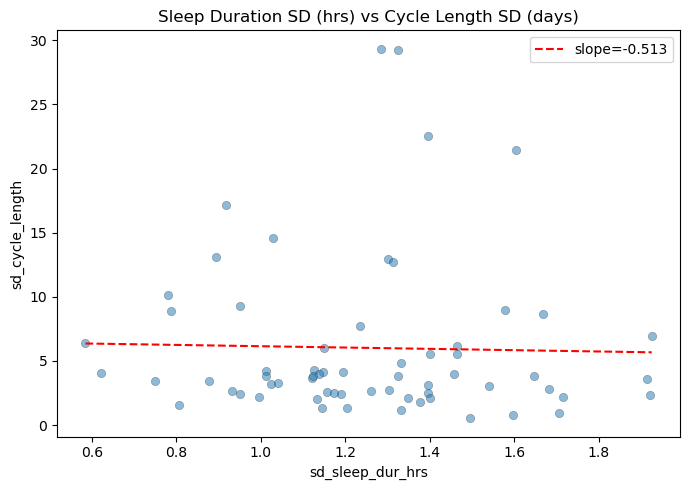

Saved: scatter_sd_sleep_dur_hrs_vs_sd_cycle_length.png


In [230]:
plot_specs = []

# From sleepavg
if "cycle_sleep" in dir() and len(cycle_sleep) > 0:
    plot_specs.append(("sleep_sd_hrs", "sd_cycle_length", cycle_sleep,
                       "Sleep Duration SD (hrs) vs Cycle Length SD (days)"))
    plot_specs.append(("avg_sleep_hrs", "sd_cycle_length", cycle_sleep,
                       "Average Sleep (hrs) vs Cycle Length SD (days)"))

# From sleeprhr
if "cycle_rhr" in dir() and len(cycle_rhr) > 0:
    plot_specs.append(("mean_within_4hr_count", "sd_cycle_length", cycle_rhr,
                       "Mean Within-4hr Count vs Cycle Length SD (days)"))

# From sleep_hr
if "cycle_hr" in dir() and len(cycle_hr) > 0:
    for xvar, title_prefix in [
        ("sd_hrv", "HRV SD"),
        ("mean_rhr", "Mean Resting HR"),
        ("sd_sleep_dur_hrs", "Sleep Duration SD (hrs)"),
    ]:
        subset = cycle_hr.dropna(subset=[xvar, "sd_cycle_length"])
        if len(subset) > 5:
            plot_specs.append((xvar, "sd_cycle_length", subset,
                               f"{title_prefix} vs Cycle Length SD (days)"))

for xvar, yvar, df, title in plot_specs:
    plt.figure(figsize=(7, 5))
    plt.scatter(df[xvar], df[yvar], alpha=0.5, edgecolors="k", linewidth=0.3)
    # OLS trend line
    mask = df[[xvar, yvar]].dropna().index
    if len(mask) > 2:
        z = np.polyfit(df.loc[mask, xvar], df.loc[mask, yvar], 1)
        p = np.poly1d(z)
        x_line = np.linspace(df[xvar].min(), df[xvar].max(), 100)
        plt.plot(x_line, p(x_line), "r--", linewidth=1.5, label=f"slope={z[0]:.3f}")
        plt.legend()
    plt.xlabel(xvar)
    plt.ylabel(yvar)
    plt.title(title)
    plt.tight_layout()
    fname = f"scatter_{xvar}_vs_{yvar}.png".replace(" ", "_")
    plt.savefig(OUT_DIR / fname, dpi=200)
    plt.show()
    print(f"Saved: {fname}")

In [231]:
sleep_hr_raw = pd.read_csv(DOWNLOADS / "sleep_hr.csv", nrows=5, low_memory=False)
print("Columns in sleep_hr.csv:")
print(sleep_hr_raw.columns.tolist())
print(f"\nNumber of columns: {len(sleep_hr_raw.columns)}")
print("\nFirst 5 rows:")
display(sleep_hr_raw.head())
print("\nData types:")
print(sleep_hr_raw.dtypes)

Columns in sleep_hr.csv:
['day', 'type', 'total_sleep_duration', 'average_breath', 'average_heart_rate', 'average_hrv', 'awake_time', 'bedtime_end', 'bedtime_start', 'deep_sleep_duration', 'efficiency', 'heart_rate', 'hrv', 'latency', 'light_sleep_duration', 'low_battery_alert', 'lowest_heart_rate', 'movement_30_sec', 'period', 'readiness', 'readiness_score_delta', 'rem_sleep_duration', 'restless_periods', 'sleep_algorithm_version', 'sleep_analysis_reason', 'sleep_phase_30_sec', 'sleep_phase_5_min', 'sleep_score_delta', 'time_in_bed', 'id', 'participant_id', 'name', 'email', 'group', 'lowest_bpm', 'lowest_bpm_time', 'within_four_hours']

Number of columns: 37

First 5 rows:


,day,type,total_sleep_duration,average_breath,average_heart_rate,average_hrv,awake_time,bedtime_end,bedtime_start,deep_sleep_duration,...,sleep_score_delta,time_in_bed,id,participant_id,name,email,group,lowest_bpm,lowest_bpm_time,within_four_hours
0,2024-09-14,long_sleep,25110,16.875,67.000,49.0,2079,2024-09-14 16:10:38+00:00,2024-09-14 08:37:29+00:00,7530,...,0.0,27189,071a9875-48fa-4083-92a3-bd0c4b52cae7,02244c09-9687-46b8-901a-59e034468d2a,10227,sandyg8005@gmail.com,STIGMA,62.0,2024-09-14 12:53:44+00:00,False
1,2024-09-15,long_sleep,33030,16.750,65.750,52.0,1825,2024-09-15 17:10:56+00:00,2024-09-15 07:30:01+00:00,7440,...,0.0,34855,2dde3d12-89f4-4816-86a0-29cab124362d,02244c09-9687-46b8-901a-59e034468d2a,10227,sandyg8005@gmail.com,STIGMA,58.0,2024-09-15 10:09:17+00:00,True
2,2024-09-16,long_sleep,19500,17.625,66.625,39.0,2280,2024-09-16 14:10:29+00:00,2024-09-16 08:07:29+00:00,5730,...,0.0,21780,806ef357-b1ab-4cdb-8e40-d50dfc0a66db,02244c09-9687-46b8-901a-59e034468d2a,10227,sandyg8005@gmail.com,STIGMA,62.0,2024-09-16 11:37:44+00:00,True
3,2024-09-17,long_sleep,14160,17.125,67.625,47.0,1888,2024-09-17 14:38:28+00:00,2024-09-17 10:11:00+00:00,3690,...,0.0,16048,d238dd7a-e004-4f34-91ce-5e9ad95777a9,02244c09-9687-46b8-901a-59e034468d2a,10227,sandyg8005@gmail.com,STIGMA,61.0,2024-09-17 14:07:44+00:00,True
4,2024-09-18,long_sleep,21780,17.000,72.750,32.0,1750,2024-09-18 14:42:12+00:00,2024-09-18 08:10:02+00:00,5520,...,0.0,23530,7593aa1e-15d4-4982-bcdb-4a00f44696dd,02244c09-9687-46b8-901a-59e034468d2a,10227,sandyg8005@gmail.com,STIGMA,63.0,2024-09-18 14:07:46+00:00,False



Data types:
day                         object
type                        object
total_sleep_duration         int64
average_breath             float64
average_heart_rate         float64
average_hrv                float64
awake_time                   int64
bedtime_end                 object
bedtime_start               object
deep_sleep_duration          int64
efficiency                   int64
heart_rate                  object
hrv                         object
latency                      int64
light_sleep_duration         int64
low_battery_alert             bool
lowest_heart_rate          float64
movement_30_sec             object
period                       int64
readiness                   object
readiness_score_delta      float64
rem_sleep_duration           int64
restless_periods             int64
sleep_algorithm_version     object
sleep_analysis_reason      float64
sleep_phase_30_sec          object
sleep_phase_5_min           object
sleep_score_delta          float64
time_in

In [232]:
# Building cycle-level dataframe with stress matched to each cycle
# Each row = one cycle for one person
cycle_df = cycles[["id_num", "menzie_start", "cycle_length_days"]].copy()

# Compute cycle end date
cycle_df["cycle_end"] = cycle_df["menzie_start"] + pd.to_timedelta(cycle_df["cycle_length_days"], unit="D")

# Compute each person's mean cycle length (for calculating deviation)
person_mean = cycle_df.groupby("id_num")["cycle_length_days"].transform("mean")
cycle_df["cycle_deviation"] = cycle_df["cycle_length_days"] - person_mean
cycle_df["abs_cycle_deviation"] = cycle_df["cycle_deviation"].abs()

print(f"Total cycles: {len(cycle_df)}")
print(f"Unique participants: {cycle_df['id_num'].nunique()}")
cycle_df.head(10)

Total cycles: 2003
Unique participants: 301


,id_num,menzie_start,cycle_length_days,cycle_end,cycle_deviation,abs_cycle_deviation
6,10199,2024-08-29,31.0,2024-09-29,1.750000,1.750000
10,10199,2024-09-29,26.0,2024-10-25,-3.250000,3.250000
14,10199,2024-10-25,29.0,2024-11-23,-0.250000,0.250000
18,10199,2024-11-23,31.0,2024-12-24,1.750000,1.750000
27,10200,2024-09-26,24.0,2024-10-20,-0.052632,0.052632
30,10200,2024-10-20,24.0,2024-11-13,-0.052632,0.052632
33,10200,2024-11-13,23.0,2024-12-06,-1.052632,1.052632
38,10200,2024-12-06,24.0,2024-12-30,-0.052632,0.052632
41,10200,2024-12-30,28.0,2025-01-27,3.947368,3.947368
45,10200,2025-01-27,26.0,2025-02-22,1.947368,1.947368


In [233]:
cycle_df["id_num"] = pd.to_numeric(cycle_df["id_num"], errors="coerce")

In [234]:
# Preparing stress data with parseable dates
# Stress weeklies file has a "date_range" column like "2024-09-15 to 2024-09-21"
# Parse the start date of each week so we can match weeks to cycles

stress_weekly = stress.copy()

# Parse the week start date from the date_range column
if "date_range" in stress_weekly.columns:
    stress_weekly["week_start"] = pd.to_datetime(
        stress_weekly["date_range"].str.split(" to ").str[0], errors="coerce"
    )
elif "week_start" in stress_weekly.columns:
    stress_weekly["week_start"] = pd.to_datetime(stress_weekly["week_start"], errors="coerce")
elif "day" in stress_weekly.columns:
    stress_weekly["week_start"] = pd.to_datetime(stress_weekly["day"], errors="coerce")

# Make sure name is numeric to match id_num
stress_weekly["id_num"] = pd.to_numeric(stress_weekly["name"].astype(str).str.strip(), errors="coerce")

# Keep only what we need
stress_cols = ["id_num", "week_start", "stress_high_sum"]
for col in stress_cols:
    if col not in stress_weekly.columns:
        print(f"⚠️  Column '{col}' not found. Available: {stress_weekly.columns.tolist()}")

stress_weekly = stress_weekly[stress_cols].dropna()
stress_weekly["stress_high_sum"] = pd.to_numeric(stress_weekly["stress_high_sum"], errors="coerce")

print(f"Stress weekly rows: {len(stress_weekly)}")
print(f"Unique participants with stress data: {stress_weekly['id_num'].nunique()}")
stress_weekly.head()

Stress weekly rows: 15076
Unique participants with stress data: 332


,id_num,week_start,stress_high_sum
0,10200,2024-09-15,23400
1,10200,2024-09-22,49500
2,10200,2024-09-29,50400
3,10200,2024-10-06,30600
4,10200,2024-10-13,27900


In [235]:
# Match stress weeks to cycle window
# For each cycle, find all stress weeks where the week_start falls within
# [menzie_start, cycle_end), then average the stress over those weeks.

matched_rows = []

for _, cyc in cycle_df.iterrows():
    pid = cyc["id_num"]
    c_start = cyc["menzie_start"]
    c_end = cyc["cycle_end"]
    
    # Get this person's stress weeks that overlap with this cycle
    mask = (
        (stress_weekly["id_num"] == pid) &
        (stress_weekly["week_start"] >= c_start) &
        (stress_weekly["week_start"] < c_end)
    )
    weeks = stress_weekly.loc[mask]
    
    if len(weeks) > 0:
        matched_rows.append({
            "id_num": pid,
            "menzie_start": c_start,
            "cycle_end": c_end,
            "cycle_length_days": cyc["cycle_length_days"],
            "cycle_deviation": cyc["cycle_deviation"],
            "abs_cycle_deviation": cyc["abs_cycle_deviation"],
            "cycle_stress_mean": weeks["stress_high_sum"].mean(),
            "n_stress_weeks": len(weeks),
        })

cycle_stress = pd.DataFrame(matched_rows)
print(f"Cycles with matched stress data: {len(cycle_stress)}")
print(f"Unique participants: {cycle_stress['id_num'].nunique()}")
print(f"\nStress weeks matched per cycle:")
print(cycle_stress["n_stress_weeks"].describe())
cycle_stress.head(10)

Cycles with matched stress data: 1913
Unique participants: 283

Stress weeks matched per cycle:
count    1913.000000
mean        4.186618
std         1.265154
min         1.000000
25%         4.000000
50%         4.000000
75%         5.000000
max        25.000000
Name: n_stress_weeks, dtype: float64


,id_num,menzie_start,cycle_end,cycle_length_days,cycle_deviation,abs_cycle_deviation,cycle_stress_mean,n_stress_weeks
0,10200,2024-09-26,2024-10-20,24.0,-0.052632,0.052632,36300.0,3
1,10200,2024-10-20,2024-11-13,24.0,-0.052632,0.052632,28125.0,4
2,10200,2024-11-13,2024-12-06,23.0,-1.052632,1.052632,66000.0,3
3,10200,2024-12-06,2024-12-30,24.0,-0.052632,0.052632,47025.0,4
4,10200,2024-12-30,2025-01-27,28.0,3.947368,3.947368,31275.0,4
5,10200,2025-01-27,2025-02-22,26.0,1.947368,1.947368,35100.0,3
6,10200,2025-02-23,2025-03-20,25.0,0.947368,0.947368,40275.0,4
7,10200,2025-03-20,2025-04-13,24.0,-0.052632,0.052632,44400.0,3
8,10200,2025-04-13,2025-05-07,24.0,-0.052632,0.052632,49275.0,4
9,10200,2025-05-07,2025-05-31,24.0,-0.052632,0.052632,63000.0,3


In [236]:
# Add person-level covariates (age, BMI)
cycle_stress = cycle_stress.merge(covars[["id_num", "years", "bmi"]], on="id_num", how="left")
cycle_stress = cycle_stress.dropna(subset=["cycle_stress_mean", "abs_cycle_deviation", "years", "bmi"])

# Z-score the predictors
from scipy.stats import zscore
cycle_stress["stress_z"] = zscore(cycle_stress["cycle_stress_mean"])
cycle_stress["age_z"] = zscore(cycle_stress["years"])
cycle_stress["bmi_z"] = zscore(cycle_stress["bmi"])

print(f"Final cycle-level dataset: {len(cycle_stress)} cycles from {cycle_stress['id_num'].nunique()} participants")
print(f"\nDescriptive stats:")
print(cycle_stress[["cycle_length_days", "abs_cycle_deviation", "cycle_stress_mean"]].describe())

Final cycle-level dataset: 1791 cycles from 235 participants

Descriptive stats:
       cycle_length_days  abs_cycle_deviation  cycle_stress_mean
count        1791.000000          1791.000000         1791.00000
mean           29.579564             3.657603        62704.14203
std             8.350908             5.140330        25275.06449
min            14.000000             0.000000            0.00000
25%            26.000000             0.916667        45900.00000
50%            28.000000             2.111111        60600.00000
75%            31.000000             4.250000        77100.00000
max           177.000000            58.500000       202200.00000


In [237]:
# Mixed-effects model - does stress during a cycle predict that cycle's irregularity? 
import statsmodels.formula.api as smf

# Model 1: Absolute deviation from person's mean cycle length
# Random intercept per person to account for repeated measures
model_cycle = smf.mixedlm(
    "abs_cycle_deviation ~ stress_z + age_z + bmi_z",
    data=cycle_stress,
    groups=cycle_stress["id_num"]
).fit()
print("=" * 70)
print("MODEL 1: Cycle deviation ~ stress during cycle (mixed-effects)")
print("=" * 70)
print(model_cycle.summary())

MODEL 1: Cycle deviation ~ stress during cycle (mixed-effects)
              Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: abs_cycle_deviation
No. Observations: 1791    Method:             REML               
No. Groups:       235     Scale:              16.2874            
Min. group size:  1       Log-Likelihood:     -5275.9819         
Max. group size:  19      Converged:          Yes                
Mean group size:  7.6                                            
-------------------------------------------------------------------
               Coef.    Std.Err.     z      P>|z|   [0.025   0.975]
-------------------------------------------------------------------
Intercept       4.026      0.285   14.146   0.000    3.469    4.584
stress_z        0.046      0.135    0.342   0.732   -0.218    0.310
age_z          -0.038      0.293   -0.131   0.896   -0.614    0.537
bmi_z          -0.255      0.311   -0.821   0.412   -0.864    0.354
Group Var    

In [238]:
# Model 2: Raw (signed) deviation - does stress make cycles longer or shorter?
model_signed = smf.mixedlm(
    "cycle_deviation ~ stress_z + age_z + bmi_z",
    data=cycle_stress,
    groups=cycle_stress["id_num"]
).fit()
print("=" * 70)
print("MODEL 2: Cycle deviation (signed) ~ stress during cycle (mixed-effects)")
print("=" * 70)
print(model_signed.summary())

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(


MODEL 2: Cycle deviation (signed) ~ stress during cycle (mixed-effects)
            Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: cycle_deviation
No. Observations: 1791    Method:             REML           
No. Groups:       235     Scale:              39.8721        
Min. group size:  1       Log-Likelihood:     -5847.3632     
Max. group size:  19      Converged:          No             
Mean group size:  7.6                                        
--------------------------------------------------------------
               Coef.   Std.Err.    z     P>|z|  [0.025  0.975]
--------------------------------------------------------------
Intercept       0.005     0.152   0.031  0.975  -0.293   0.303
stress_z       -0.057     0.153  -0.373  0.709  -0.357   0.243
age_z          -0.006     0.156  -0.037  0.970  -0.311   0.299
bmi_z          -0.004     0.154  -0.027  0.978  -0.306   0.298
Group Var       0.167                                         



/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2206: ConvergenceWarning: MixedLM optimization failed, trying a different optimizer may help.
  warnings.warn(msg, ConvergenceWarning)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2218: ConvergenceWarning: Gradient optimization failed, |grad| = 109.259833
  warnings.warn(msg, ConvergenceWarning)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


In [239]:
# Model 3: Raw cycle length — does stress predict longer/shorter cycles? 
model_length = smf.mixedlm(
    "cycle_length_days ~ stress_z + age_z + bmi_z",
    data=cycle_stress,
    groups=cycle_stress["id_num"]
).fit()
print("=" * 70)
print("MODEL 3: Cycle length ~ stress during cycle (mixed-effects)")
print("=" * 70)
print(model_length.summary())

MODEL 3: Cycle length ~ stress during cycle (mixed-effects)
             Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: cycle_length_days
No. Observations: 1791    Method:             REML             
No. Groups:       235     Scale:              47.1852          
Min. group size:  1       Log-Likelihood:     -6215.7908       
Max. group size:  19      Converged:          Yes              
Mean group size:  7.6                                          
-----------------------------------------------------------------
             Coef.    Std.Err.     z      P>|z|   [0.025   0.975]
-----------------------------------------------------------------
Intercept    30.540      0.463   65.917   0.000   29.632   31.448
stress_z     -0.074      0.228   -0.323   0.747   -0.520    0.373
age_z        -0.419      0.477   -0.879   0.379   -1.354    0.515
bmi_z        -0.138      0.503   -0.274   0.784   -1.124    0.849
Group Var    41.403      0.899             

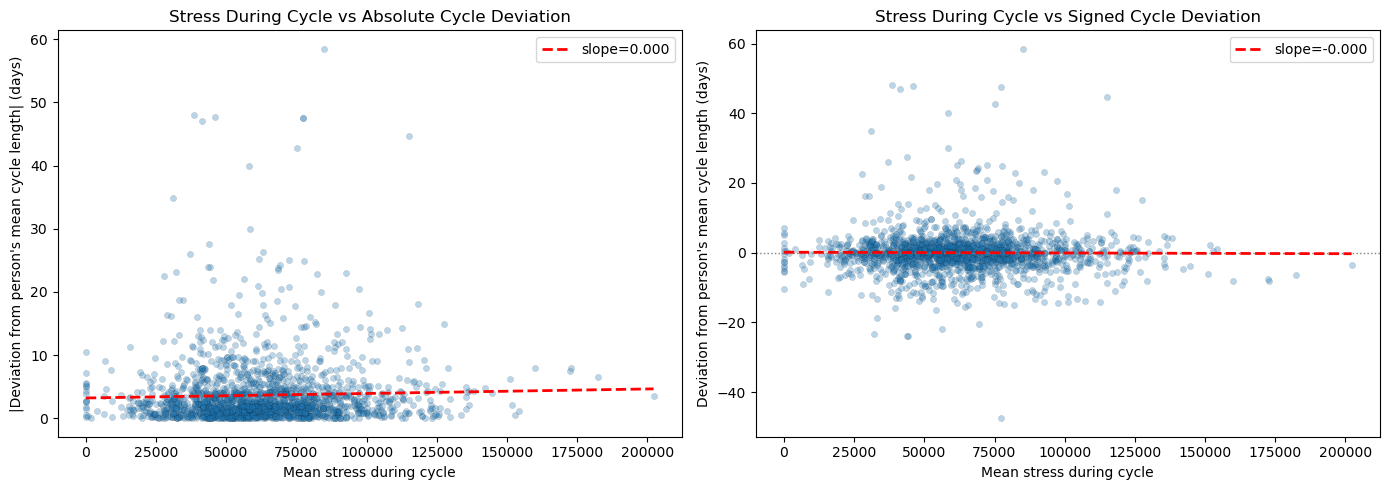

In [240]:
# Scatter plot: stress during cycle vs cycle deviation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Absolute deviation
ax = axes[0]
ax.scatter(cycle_stress["cycle_stress_mean"], cycle_stress["abs_cycle_deviation"],
           alpha=0.3, edgecolors="k", linewidth=0.2, s=20)
z = np.polyfit(cycle_stress["cycle_stress_mean"], cycle_stress["abs_cycle_deviation"], 1)
x_line = np.linspace(cycle_stress["cycle_stress_mean"].min(), cycle_stress["cycle_stress_mean"].max(), 100)
ax.plot(x_line, np.poly1d(z)(x_line), "r--", linewidth=2, label=f"slope={z[0]:.3f}")
ax.set_xlabel("Mean stress during cycle")
ax.set_ylabel("|Deviation from person's mean cycle length| (days)")
ax.set_title("Stress During Cycle vs Absolute Cycle Deviation")
ax.legend()

# Signed deviation
ax = axes[1]
ax.scatter(cycle_stress["cycle_stress_mean"], cycle_stress["cycle_deviation"],
           alpha=0.3, edgecolors="k", linewidth=0.2, s=20)
ax.axhline(0, color="gray", linestyle=":", linewidth=1)
z = np.polyfit(cycle_stress["cycle_stress_mean"], cycle_stress["cycle_deviation"], 1)
ax.plot(x_line, np.poly1d(z)(x_line), "r--", linewidth=2, label=f"slope={z[0]:.3f}")
ax.set_xlabel("Mean stress during cycle")
ax.set_ylabel("Deviation from person's mean cycle length (days)")
ax.set_title("Stress During Cycle vs Signed Cycle Deviation")
ax.legend()

plt.tight_layout()
plt.savefig(OUT_DIR / "cycle_level_stress_vs_deviation.png", dpi=200)
plt.show()

In [241]:
# Prepare sleep weekly data with parseable dates
sleep_weekly = stress_sleep.copy()

if "date_range" in sleep_weekly.columns:
    sleep_weekly["week_start"] = pd.to_datetime(
        sleep_weekly["date_range"].str.split(" to ").str[0], errors="coerce"
    )
elif "week_start" in sleep_weekly.columns:
    sleep_weekly["week_start"] = pd.to_datetime(sleep_weekly["week_start"], errors="coerce")

sleep_weekly["id_num"] = pd.to_numeric(sleep_weekly["name"].astype(str).str.strip(), errors="coerce")
sleep_weekly["SD_bedtime_start_min"] = pd.to_numeric(sleep_weekly["SD_bedtime_start_min"], errors="coerce")

sleep_weekly = sleep_weekly[["id_num", "week_start", "SD_bedtime_start_min"]].dropna()

print(f"Sleep weekly rows: {len(sleep_weekly)}")
print(f"Unique participants with sleep data: {sleep_weekly['id_num'].nunique()}")
sleep_weekly.head()

Sleep weekly rows: 14033
Unique participants with sleep data: 330


,id_num,week_start,SD_bedtime_start_min
0,10200,2024-09-15,9.366667
1,10200,2024-09-22,24.650000
2,10200,2024-09-29,34.100000
3,10200,2024-10-06,54.716667
4,10200,2024-10-13,33.666667


In [242]:
# Match sleep weeks to each cycle window
matched_sleep = []

for _, cyc in cycle_df.iterrows():
    pid = cyc["id_num"]
    c_start = cyc["menzie_start"]
    c_end = cyc["cycle_end"]

    mask = (
        (sleep_weekly["id_num"] == pid) &
        (sleep_weekly["week_start"] >= c_start) &
        (sleep_weekly["week_start"] < c_end)
    )
    weeks = sleep_weekly.loc[mask]

    if len(weeks) > 0:
        matched_sleep.append({
            "id_num": pid,
            "menzie_start": c_start,
            "cycle_end": c_end,
            "cycle_length_days": cyc["cycle_length_days"],
            "cycle_deviation": cyc["cycle_deviation"],
            "abs_cycle_deviation": cyc["abs_cycle_deviation"],
            "cycle_sleep_sd_mean": weeks["SD_bedtime_start_min"].mean(),
            "n_sleep_weeks": len(weeks),
        })

cycle_sleep_lvl = pd.DataFrame(matched_sleep)
print(f"Cycles with matched sleep data: {len(cycle_sleep_lvl)}")
print(f"Unique participants: {cycle_sleep_lvl['id_num'].nunique()}")
print(f"\nSleep weeks matched per cycle:")
print(cycle_sleep_lvl["n_sleep_weeks"].describe())
cycle_sleep_lvl.head(10)

Cycles with matched sleep data: 1911
Unique participants: 283

Sleep weeks matched per cycle:
count    1911.000000
mean        4.155416
std         1.288865
min         1.000000
25%         4.000000
50%         4.000000
75%         4.000000
max        25.000000
Name: n_sleep_weeks, dtype: float64


,id_num,menzie_start,cycle_end,cycle_length_days,cycle_deviation,abs_cycle_deviation,cycle_sleep_sd_mean,n_sleep_weeks
0,10200,2024-09-26,2024-10-20,24.0,-0.052632,0.052632,40.827778,3
1,10200,2024-10-20,2024-11-13,24.0,-0.052632,0.052632,30.779167,4
2,10200,2024-11-13,2024-12-06,23.0,-1.052632,1.052632,49.533333,3
3,10200,2024-12-06,2024-12-30,24.0,-0.052632,0.052632,50.487500,4
4,10200,2024-12-30,2025-01-27,28.0,3.947368,3.947368,45.912500,4
5,10200,2025-01-27,2025-02-22,26.0,1.947368,1.947368,19.011111,3
6,10200,2025-02-23,2025-03-20,25.0,0.947368,0.947368,54.608333,4
7,10200,2025-03-20,2025-04-13,24.0,-0.052632,0.052632,23.361111,3
8,10200,2025-04-13,2025-05-07,24.0,-0.052632,0.052632,33.383333,4
9,10200,2025-05-07,2025-05-31,24.0,-0.052632,0.052632,34.350000,3


In [243]:
# Add covariates and z-score 
cycle_sleep_lvl = cycle_sleep_lvl.merge(covars[["id_num", "years", "bmi"]], on="id_num", how="left")
cycle_sleep_lvl = cycle_sleep_lvl.dropna(subset=["cycle_sleep_sd_mean", "abs_cycle_deviation", "years", "bmi"])

cycle_sleep_lvl["sleep_z"] = zscore(cycle_sleep_lvl["cycle_sleep_sd_mean"])
cycle_sleep_lvl["age_z"] = zscore(cycle_sleep_lvl["years"])
cycle_sleep_lvl["bmi_z"] = zscore(cycle_sleep_lvl["bmi"])

print(f"Final sleep cycle-level dataset: {len(cycle_sleep_lvl)} cycles from {cycle_sleep_lvl['id_num'].nunique()} participants")
print(cycle_sleep_lvl[["cycle_length_days", "abs_cycle_deviation", "cycle_sleep_sd_mean"]].describe())

Final sleep cycle-level dataset: 1789 cycles from 235 participants
       cycle_length_days  abs_cycle_deviation  cycle_sleep_sd_mean
count        1789.000000          1789.000000          1789.000000
mean           29.585802             3.658339            73.095053
std             8.352888             5.142507            34.898370
min            14.000000             0.000000             0.000000
25%            26.000000             0.916667            50.754167
50%            28.000000             2.111111            67.425000
75%            31.000000             4.250000            87.456667
max           177.000000            58.500000           413.996667


In [244]:
# Mixed-effects models: sleep variability during cycle 

# Model 1: Absolute deviation
model_sleep_abs = smf.mixedlm(
    "abs_cycle_deviation ~ sleep_z + age_z + bmi_z",
    data=cycle_sleep_lvl,
    groups=cycle_sleep_lvl["id_num"]
).fit()
print("=" * 70)
print("SLEEP MODEL 1: |Cycle deviation| ~ sleep SD during cycle")
print("=" * 70)
print(model_sleep_abs.summary())

# Model 2: Signed deviation
model_sleep_signed = smf.mixedlm(
    "cycle_deviation ~ sleep_z + age_z + bmi_z",
    data=cycle_sleep_lvl,
    groups=cycle_sleep_lvl["id_num"]
).fit()
print("\n" + "=" * 70)
print("SLEEP MODEL 2: Cycle deviation (signed) ~ sleep SD during cycle")
print("=" * 70)
print(model_sleep_signed.summary())

# Model 3: Raw cycle length
model_sleep_length = smf.mixedlm(
    "cycle_length_days ~ sleep_z + age_z + bmi_z",
    data=cycle_sleep_lvl,
    groups=cycle_sleep_lvl["id_num"]
).fit()
print("\n" + "=" * 70)
print("SLEEP MODEL 3: Cycle length ~ sleep SD during cycle")
print("=" * 70)
print(model_sleep_length.summary())

SLEEP MODEL 1: |Cycle deviation| ~ sleep SD during cycle
              Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: abs_cycle_deviation
No. Observations: 1789    Method:             REML               
No. Groups:       235     Scale:              16.3020            
Min. group size:  1       Log-Likelihood:     -5270.9240         
Max. group size:  19      Converged:          Yes                
Mean group size:  7.6                                            
-------------------------------------------------------------------
               Coef.    Std.Err.     z      P>|z|   [0.025   0.975]
-------------------------------------------------------------------
Intercept       4.026      0.285   14.144   0.000    3.468    4.584
sleep_z        -0.022      0.132   -0.167   0.867   -0.281    0.237
age_z          -0.045      0.293   -0.153   0.878   -0.619    0.529
bmi_z          -0.257      0.311   -0.826   0.409   -0.865    0.352
Group Var      15.9

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(



SLEEP MODEL 2: Cycle deviation (signed) ~ sleep SD during cycle
            Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: cycle_deviation
No. Observations: 1789    Method:             REML           
No. Groups:       235     Scale:              39.8994        
Min. group size:  1       Log-Likelihood:     -5841.3883     
Max. group size:  19      Converged:          Yes            
Mean group size:  7.6                                        
--------------------------------------------------------------
               Coef.   Std.Err.    z     P>|z|  [0.025  0.975]
--------------------------------------------------------------
Intercept       0.008     0.152   0.049  0.961  -0.291   0.306
sleep_z        -0.061     0.151  -0.403  0.687  -0.357   0.235
age_z          -0.006     0.154  -0.037  0.971  -0.308   0.297
bmi_z           0.002     0.154   0.016  0.987  -0.299   0.304
Group Var       0.164                                         


SLEEP M

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


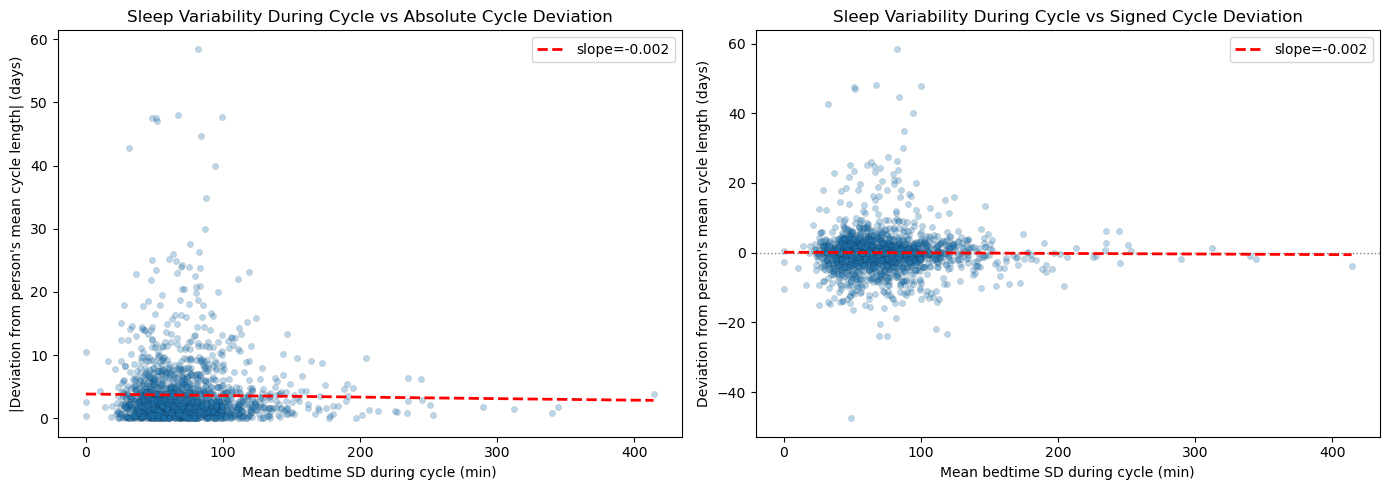

In [245]:
# Scatter plots: sleep SD during cycle vs cycle deviation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(cycle_sleep_lvl["cycle_sleep_sd_mean"], cycle_sleep_lvl["abs_cycle_deviation"],
           alpha=0.3, edgecolors="k", linewidth=0.2, s=20)
z = np.polyfit(cycle_sleep_lvl["cycle_sleep_sd_mean"], cycle_sleep_lvl["abs_cycle_deviation"], 1)
x_line = np.linspace(cycle_sleep_lvl["cycle_sleep_sd_mean"].min(), cycle_sleep_lvl["cycle_sleep_sd_mean"].max(), 100)
ax.plot(x_line, np.poly1d(z)(x_line), "r--", linewidth=2, label=f"slope={z[0]:.3f}")
ax.set_xlabel("Mean bedtime SD during cycle (min)")
ax.set_ylabel("|Deviation from person's mean cycle length| (days)")
ax.set_title("Sleep Variability During Cycle vs Absolute Cycle Deviation")
ax.legend()

ax = axes[1]
ax.scatter(cycle_sleep_lvl["cycle_sleep_sd_mean"], cycle_sleep_lvl["cycle_deviation"],
           alpha=0.3, edgecolors="k", linewidth=0.2, s=20)
ax.axhline(0, color="gray", linestyle=":", linewidth=1)
z = np.polyfit(cycle_sleep_lvl["cycle_sleep_sd_mean"], cycle_sleep_lvl["cycle_deviation"], 1)
ax.plot(x_line, np.poly1d(z)(x_line), "r--", linewidth=2, label=f"slope={z[0]:.3f}")
ax.set_xlabel("Mean bedtime SD during cycle (min)")
ax.set_ylabel("Deviation from person's mean cycle length (days)")
ax.set_title("Sleep Variability During Cycle vs Signed Cycle Deviation")
ax.legend()

plt.tight_layout()
plt.savefig(OUT_DIR / "cycle_level_sleep_vs_deviation.png", dpi=200)
plt.show()

In [246]:
# Prepare exercise weekly data with parseable dates
exercise_weekly = exercise.copy()

if "date_range" in exercise_weekly.columns:
    exercise_weekly["week_start"] = pd.to_datetime(
        exercise_weekly["date_range"].str.split(" to ").str[0], errors="coerce"
    )
elif "week_start" in exercise_weekly.columns:
    exercise_weekly["week_start"] = pd.to_datetime(exercise_weekly["week_start"], errors="coerce")

exercise_weekly["id_num"] = pd.to_numeric(exercise_weekly["name"].astype(str).str.strip(), errors="coerce")
exercise_weekly["active_calories"] = pd.to_numeric(exercise_weekly["active_calories"], errors="coerce")

exercise_weekly = exercise_weekly[["id_num", "week_start", "active_calories"]].dropna()

print(f"Exercise weekly rows: {len(exercise_weekly)}")
print(f"Unique participants with exercise data: {exercise_weekly['id_num'].nunique()}")
exercise_weekly.head()

Exercise weekly rows: 11555
Unique participants with exercise data: 327


,id_num,week_start,active_calories
0,10200,2024-09-09,1240
1,10200,2024-09-16,4134
2,10200,2024-09-23,2935
3,10200,2024-09-30,3064
4,10200,2024-10-07,3186


In [247]:
# Match exercise weeks to each cycle window 
matched_exercise = []

for _, cyc in cycle_df.iterrows():
    pid = cyc["id_num"]
    c_start = cyc["menzie_start"]
    c_end = cyc["cycle_end"]

    mask = (
        (exercise_weekly["id_num"] == pid) &
        (exercise_weekly["week_start"] >= c_start) &
        (exercise_weekly["week_start"] < c_end)
    )
    weeks = exercise_weekly.loc[mask]

    if len(weeks) > 0:
        matched_exercise.append({
            "id_num": pid,
            "menzie_start": c_start,
            "cycle_end": c_end,
            "cycle_length_days": cyc["cycle_length_days"],
            "cycle_deviation": cyc["cycle_deviation"],
            "abs_cycle_deviation": cyc["abs_cycle_deviation"],
            "cycle_exercise_mean": weeks["active_calories"].mean(),
            "n_exercise_weeks": len(weeks),
        })

cycle_exercise_lvl = pd.DataFrame(matched_exercise)
print(f"Cycles with matched exercise data: {len(cycle_exercise_lvl)}")
print(f"Unique participants: {cycle_exercise_lvl['id_num'].nunique()}")
print(f"\nExercise weeks matched per cycle:")
print(cycle_exercise_lvl["n_exercise_weeks"].describe())
cycle_exercise_lvl.head(10)

Cycles with matched exercise data: 1770
Unique participants: 269

Exercise weeks matched per cycle:
count    1770.000000
mean        4.084746
std         1.333418
min         1.000000
25%         4.000000
50%         4.000000
75%         4.000000
max        26.000000
Name: n_exercise_weeks, dtype: float64


,id_num,menzie_start,cycle_end,cycle_length_days,cycle_deviation,abs_cycle_deviation,cycle_exercise_mean,n_exercise_weeks
0,10200,2024-09-26,2024-10-20,24.0,-0.052632,0.052632,3281.333333,3
1,10200,2024-10-20,2024-11-13,24.0,-0.052632,0.052632,3209.500000,4
2,10200,2024-11-13,2024-12-06,23.0,-1.052632,1.052632,2810.333333,3
3,10200,2024-12-06,2024-12-30,24.0,-0.052632,0.052632,2804.333333,3
4,10200,2024-12-30,2025-01-27,28.0,3.947368,3.947368,3487.000000,4
5,10200,2025-01-27,2025-02-22,26.0,1.947368,1.947368,3825.500000,4
6,10200,2025-02-23,2025-03-20,25.0,0.947368,0.947368,3316.250000,4
7,10200,2025-03-20,2025-04-13,24.0,-0.052632,0.052632,2714.000000,3
8,10200,2025-04-13,2025-05-07,24.0,-0.052632,0.052632,2677.250000,4
9,10200,2025-05-07,2025-05-31,24.0,-0.052632,0.052632,2808.333333,3


In [248]:
# Add covariates and z-score
cycle_exercise_lvl = cycle_exercise_lvl.merge(covars[["id_num", "years", "bmi"]], on="id_num", how="left")
cycle_exercise_lvl = cycle_exercise_lvl.dropna(subset=["cycle_exercise_mean", "abs_cycle_deviation", "years", "bmi"])

cycle_exercise_lvl["exercise_z"] = zscore(cycle_exercise_lvl["cycle_exercise_mean"])
cycle_exercise_lvl["age_z"] = zscore(cycle_exercise_lvl["years"])
cycle_exercise_lvl["bmi_z"] = zscore(cycle_exercise_lvl["bmi"])

print(f"Final exercise cycle-level dataset: {len(cycle_exercise_lvl)} cycles from {cycle_exercise_lvl['id_num'].nunique()} participants")
print(cycle_exercise_lvl[["cycle_length_days", "abs_cycle_deviation", "cycle_exercise_mean"]].describe())

Final exercise cycle-level dataset: 1702 cycles from 234 participants
       cycle_length_days  abs_cycle_deviation  cycle_exercise_mean
count        1702.000000          1702.000000          1702.000000
mean           29.641011             3.702223          3250.656759
std             8.495240             5.221620          1565.203817
min            14.000000             0.000000            50.666667
25%            26.000000             0.928571          2335.675000
50%            28.000000             2.142857          3022.416667
75%            31.000000             4.272727          3887.312500
max           177.000000            58.500000         18503.333333


In [249]:
# Mixed-effects models: exercise during cycle

# Model 1: Absolute deviation
model_ex_abs = smf.mixedlm(
    "abs_cycle_deviation ~ exercise_z + age_z + bmi_z",
    data=cycle_exercise_lvl,
    groups=cycle_exercise_lvl["id_num"]
).fit()
print("=" * 70)
print("EXERCISE MODEL 1: |Cycle deviation| ~ exercise during cycle")
print("=" * 70)
print(model_ex_abs.summary())

# Model 2: Signed deviation
model_ex_signed = smf.mixedlm(
    "cycle_deviation ~ exercise_z + age_z + bmi_z",
    data=cycle_exercise_lvl,
    groups=cycle_exercise_lvl["id_num"]
).fit()
print("\n" + "=" * 70)
print("EXERCISE MODEL 2: Cycle deviation (signed) ~ exercise during cycle")
print("=" * 70)
print(model_ex_signed.summary())

# Model 3: Raw cycle length
model_ex_length = smf.mixedlm(
    "cycle_length_days ~ exercise_z + age_z + bmi_z",
    data=cycle_exercise_lvl,
    groups=cycle_exercise_lvl["id_num"]
).fit()
print("\n" + "=" * 70)
print("EXERCISE MODEL 3: Cycle length ~ exercise during cycle")
print("=" * 70)
print(model_ex_length.summary())

EXERCISE MODEL 1: |Cycle deviation| ~ exercise during cycle
              Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: abs_cycle_deviation
No. Observations: 1702    Method:             REML               
No. Groups:       234     Scale:              16.7978            
Min. group size:  1       Log-Likelihood:     -5043.1054         
Max. group size:  18      Converged:          Yes                
Mean group size:  7.3                                            
-------------------------------------------------------------------
               Coef.    Std.Err.     z      P>|z|   [0.025   0.975]
-------------------------------------------------------------------
Intercept       4.071      0.288   14.116   0.000    3.506    4.637
exercise_z     -0.000      0.184   -0.002   0.999   -0.362    0.361
age_z          -0.041      0.296   -0.137   0.891   -0.620    0.539
bmi_z          -0.260      0.317   -0.820   0.412   -0.881    0.361
Group Var      1

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(



EXERCISE MODEL 2: Cycle deviation (signed) ~ exercise during cycle
            Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: cycle_deviation
No. Observations: 1702    Method:             REML           
No. Groups:       234     Scale:              41.0438        
Min. group size:  1       Log-Likelihood:     -5579.6193     
Max. group size:  18      Converged:          No             
Mean group size:  7.3                                        
--------------------------------------------------------------
               Coef.   Std.Err.    z     P>|z|  [0.025  0.975]
--------------------------------------------------------------
Intercept       0.062     0.157   0.393  0.694  -0.246   0.369
exercise_z      0.048     0.157   0.304  0.761  -0.260   0.355
age_z           0.024     0.158   0.149  0.882  -0.287   0.334
bmi_z          -0.002     0.159  -0.015  0.988  -0.313   0.308
Group Var       0.083                                         


EXER

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2206: ConvergenceWarning: MixedLM optimization failed, trying a different optimizer may help.
  warnings.warn(msg, ConvergenceWarning)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2218: ConvergenceWarning: Gradient optimization failed, |grad| = 71.662735
  warnings.warn(msg, ConvergenceWarning)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


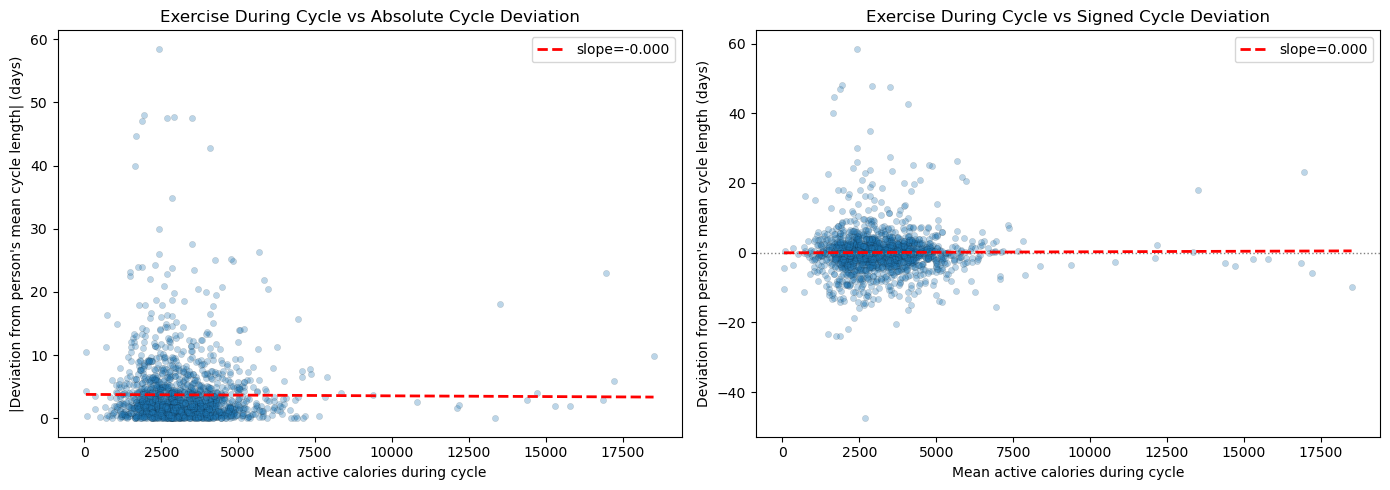

In [250]:
# Scatter plots: exercise during cycle vs cycle deviation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(cycle_exercise_lvl["cycle_exercise_mean"], cycle_exercise_lvl["abs_cycle_deviation"],
           alpha=0.3, edgecolors="k", linewidth=0.2, s=20)
z = np.polyfit(cycle_exercise_lvl["cycle_exercise_mean"], cycle_exercise_lvl["abs_cycle_deviation"], 1)
x_line = np.linspace(cycle_exercise_lvl["cycle_exercise_mean"].min(), cycle_exercise_lvl["cycle_exercise_mean"].max(), 100)
ax.plot(x_line, np.poly1d(z)(x_line), "r--", linewidth=2, label=f"slope={z[0]:.3f}")
ax.set_xlabel("Mean active calories during cycle")
ax.set_ylabel("|Deviation from person's mean cycle length| (days)")
ax.set_title("Exercise During Cycle vs Absolute Cycle Deviation")
ax.legend()

ax = axes[1]
ax.scatter(cycle_exercise_lvl["cycle_exercise_mean"], cycle_exercise_lvl["cycle_deviation"],
           alpha=0.3, edgecolors="k", linewidth=0.2, s=20)
ax.axhline(0, color="gray", linestyle=":", linewidth=1)
z = np.polyfit(cycle_exercise_lvl["cycle_exercise_mean"], cycle_exercise_lvl["cycle_deviation"], 1)
ax.plot(x_line, np.poly1d(z)(x_line), "r--", linewidth=2, label=f"slope={z[0]:.3f}")
ax.set_xlabel("Mean active calories during cycle")
ax.set_ylabel("Deviation from person's mean cycle length (days)")
ax.set_title("Exercise During Cycle vs Signed Cycle Deviation")
ax.legend()

plt.tight_layout()
plt.savefig(OUT_DIR / "cycle_level_exercise_vs_deviation.png", dpi=200)
plt.show()

In [251]:
# Prepare sleep_hr daily data
sleep_hr_daily = pd.read_csv(DOWNLOADS / "sleep_hr.csv", low_memory=False)
sleep_hr_daily["id_num"] = pd.to_numeric(sleep_hr_daily["name"].astype(str).str.strip(), errors="coerce")
sleep_hr_daily["day_dt"] = pd.to_datetime(sleep_hr_daily["day"], errors="coerce")

# Convert all numeric columns
numeric_cols = [
    "total_sleep_duration", "average_breath", "average_heart_rate",
    "average_hrv", "awake_time", "deep_sleep_duration", "efficiency",
    "latency", "light_sleep_duration", "lowest_heart_rate",
    "rem_sleep_duration", "restless_periods", "time_in_bed",
    "readiness_score_delta", "sleep_score_delta", "lowest_bpm"
]
for col in numeric_cols:
    if col in sleep_hr_daily.columns:
        sleep_hr_daily[col] = pd.to_numeric(sleep_hr_daily[col], errors="coerce")

sleep_hr_daily = sleep_hr_daily.dropna(subset=["id_num", "day_dt"])

print(f"Sleep HR daily rows: {len(sleep_hr_daily)}")
print(f"Unique participants: {sleep_hr_daily['id_num'].nunique()}")
print(f"Date range: {sleep_hr_daily['day_dt'].min()} to {sleep_hr_daily['day_dt'].max()}")
sleep_hr_daily.head()

Sleep HR daily rows: 27603
Unique participants: 81
Date range: 2024-08-14 00:00:00 to 2026-01-13 00:00:00


,day,type,total_sleep_duration,average_breath,average_heart_rate,average_hrv,awake_time,bedtime_end,bedtime_start,deep_sleep_duration,...,id,participant_id,name,email,group,lowest_bpm,lowest_bpm_time,within_four_hours,id_num,day_dt
0,2024-09-14,long_sleep,25110,16.875,67.000,49.0,2079,2024-09-14 16:10:38+00:00,2024-09-14 08:37:29+00:00,7530,...,071a9875-48fa-4083-92a3-bd0c4b52cae7,02244c09-9687-46b8-901a-59e034468d2a,10227,sandyg8005@gmail.com,STIGMA,62.0,2024-09-14 12:53:44+00:00,False,10227.0,2024-09-14
1,2024-09-15,long_sleep,33030,16.750,65.750,52.0,1825,2024-09-15 17:10:56+00:00,2024-09-15 07:30:01+00:00,7440,...,2dde3d12-89f4-4816-86a0-29cab124362d,02244c09-9687-46b8-901a-59e034468d2a,10227,sandyg8005@gmail.com,STIGMA,58.0,2024-09-15 10:09:17+00:00,True,10227.0,2024-09-15
2,2024-09-16,long_sleep,19500,17.625,66.625,39.0,2280,2024-09-16 14:10:29+00:00,2024-09-16 08:07:29+00:00,5730,...,806ef357-b1ab-4cdb-8e40-d50dfc0a66db,02244c09-9687-46b8-901a-59e034468d2a,10227,sandyg8005@gmail.com,STIGMA,62.0,2024-09-16 11:37:44+00:00,True,10227.0,2024-09-16
3,2024-09-17,long_sleep,14160,17.125,67.625,47.0,1888,2024-09-17 14:38:28+00:00,2024-09-17 10:11:00+00:00,3690,...,d238dd7a-e004-4f34-91ce-5e9ad95777a9,02244c09-9687-46b8-901a-59e034468d2a,10227,sandyg8005@gmail.com,STIGMA,61.0,2024-09-17 14:07:44+00:00,True,10227.0,2024-09-17
4,2024-09-18,long_sleep,21780,17.000,72.750,32.0,1750,2024-09-18 14:42:12+00:00,2024-09-18 08:10:02+00:00,5520,...,7593aa1e-15d4-4982-bcdb-4a00f44696dd,02244c09-9687-46b8-901a-59e034468d2a,10227,sandyg8005@gmail.com,STIGMA,63.0,2024-09-18 14:07:46+00:00,False,10227.0,2024-09-18


In [252]:
# Match daily sleep_hr data to each cycle window
# For each cycle, compute mean AND SD of each metric over the days in that cycle

hr_metrics = [
    "total_sleep_duration", "average_breath", "average_heart_rate",
    "average_hrv", "awake_time", "deep_sleep_duration", "efficiency",
    "latency", "light_sleep_duration", "lowest_heart_rate",
    "rem_sleep_duration", "restless_periods", "time_in_bed", "lowest_bpm"
]

matched_hr = []

for _, cyc in cycle_df.iterrows():
    pid = cyc["id_num"]
    c_start = cyc["menzie_start"]
    c_end = cyc["cycle_end"]

    mask = (
        (sleep_hr_daily["id_num"] == pid) &
        (sleep_hr_daily["day_dt"] >= c_start) &
        (sleep_hr_daily["day_dt"] < c_end)
    )
    days = sleep_hr_daily.loc[mask]

    if len(days) >= 3:  # require at least 3 days of data per cycle
        row = {
            "id_num": pid,
            "menzie_start": c_start,
            "cycle_end": c_end,
            "cycle_length_days": cyc["cycle_length_days"],
            "cycle_deviation": cyc["cycle_deviation"],
            "abs_cycle_deviation": cyc["abs_cycle_deviation"],
            "n_hr_days": len(days),
        }
        for metric in hr_metrics:
            if metric in days.columns:
                row[f"{metric}_mean"] = days[metric].mean()
                row[f"{metric}_sd"] = days[metric].std()
        matched_hr.append(row)

cycle_hr_lvl = pd.DataFrame(matched_hr)
print(f"Cycles with matched sleep_hr data: {len(cycle_hr_lvl)}")
print(f"Unique participants: {cycle_hr_lvl['id_num'].nunique()}")
print(f"\nDays matched per cycle:")
print(cycle_hr_lvl["n_hr_days"].describe())

Cycles with matched sleep_hr data: 624
Unique participants: 76

Days matched per cycle:
count    624.000000
mean      27.451923
std       10.506786
min        4.000000
25%       23.000000
50%       27.000000
75%       30.000000
max      167.000000
Name: n_hr_days, dtype: float64


In [253]:
# Add covariates
cycle_hr_lvl = cycle_hr_lvl.merge(covars[["id_num", "years", "bmi"]], on="id_num", how="left")
cycle_hr_lvl = cycle_hr_lvl.dropna(subset=["abs_cycle_deviation", "years", "bmi"])
cycle_hr_lvl["age_z"] = zscore(cycle_hr_lvl["years"])
cycle_hr_lvl["bmi_z"] = zscore(cycle_hr_lvl["bmi"])

print(f"Final sleep_hr cycle-level dataset: {len(cycle_hr_lvl)} cycles from {cycle_hr_lvl['id_num'].nunique()} participants")

Final sleep_hr cycle-level dataset: 622 cycles from 75 participants


In [254]:
# Run mixed-effects models for ALL sleep_hr metrics
# Test both the mean and the SD of each metric during the cycle

hr_predictors = []
for metric in hr_metrics:
    for suffix in ["_mean", "_sd"]:
        col = f"{metric}{suffix}"
        if col in cycle_hr_lvl.columns:
            valid = cycle_hr_lvl.dropna(subset=[col, "abs_cycle_deviation"])
            if len(valid) > 20 and valid[col].std() > 0:
                hr_predictors.append(col)

print(f"Testing {len(hr_predictors)} sleep_hr predictors:\n")

hr_results = []

for pred in hr_predictors:
    tmp = cycle_hr_lvl.dropna(subset=[pred, "abs_cycle_deviation", "years", "bmi"]).copy()
    if len(tmp) < 20:
        continue
    try:
        tmp["pred_z"] = zscore(tmp[pred])
        tmp["age_z"] = zscore(tmp["years"])
        tmp["bmi_z"] = zscore(tmp["bmi"])

        # Model: absolute deviation
        m_abs = smf.mixedlm(
            "abs_cycle_deviation ~ pred_z + age_z + bmi_z",
            data=tmp,
            groups=tmp["id_num"]
        ).fit(disp=False)

        # Model: signed deviation
        m_signed = smf.mixedlm(
            "cycle_deviation ~ pred_z + age_z + bmi_z",
            data=tmp,
            groups=tmp["id_num"]
        ).fit(disp=False)

        hr_results.append({
            "predictor": pred,
            "N_cycles": len(tmp),
            "N_participants": tmp["id_num"].nunique(),
            "abs_dev_beta": m_abs.params["pred_z"],
            "abs_dev_p": m_abs.pvalues["pred_z"],
            "abs_dev_sig": "***" if m_abs.pvalues["pred_z"] < 0.001 else
                           "**" if m_abs.pvalues["pred_z"] < 0.01 else
                           "*" if m_abs.pvalues["pred_z"] < 0.05 else "",
            "signed_dev_beta": m_signed.params["pred_z"],
            "signed_dev_p": m_signed.pvalues["pred_z"],
            "signed_dev_sig": "***" if m_signed.pvalues["pred_z"] < 0.001 else
                              "**" if m_signed.pvalues["pred_z"] < 0.01 else
                              "*" if m_signed.pvalues["pred_z"] < 0.05 else "",
        })
        print(f"  ✓ {pred}: abs β={m_abs.params['pred_z']:.3f} (p={m_abs.pvalues['pred_z']:.4f}), "
              f"signed β={m_signed.params['pred_z']:.3f} (p={m_signed.pvalues['pred_z']:.4f})")
    except Exception as e:
        print(f"  ✗ {pred}: {e}")

hr_results_df = pd.DataFrame(hr_results)
print(f"\n{'='*70}")
print("SUMMARY TABLE — Sleep HR metrics predicting cycle irregularity")
print(f"{'='*70}")
display(hr_results_df.sort_values("abs_dev_p"))

Testing 28 sleep_hr predictors:



/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood opti

  ✓ total_sleep_duration_mean: abs β=-0.291 (p=0.3707), signed β=-0.024 (p=0.9347)


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood opti

  ✓ total_sleep_duration_sd: abs β=-0.365 (p=0.1908), signed β=-0.109 (p=0.7129)


...

  ✓ lowest_bpm_mean: abs β=-0.128 (p=0.8001), signed β=-0.189 (p=0.5275)


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(


  ✓ lowest_bpm_sd: abs β=-0.029 (p=0.9079), signed β=-0.064 (p=0.8340)

SUMMARY TABLE — Sleep HR metrics predicting cycle irregularity


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2206: ConvergenceWarning: MixedLM optimization failed, trying a different optimizer may help.
  warnings.warn(msg, ConvergenceWarning)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2218: ConvergenceWarning: Gradient optimization failed, |grad| = 14.585597
  warnings.warn(msg, ConvergenceWarning)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


,predictor,N_cycles,N_participants,abs_dev_beta,abs_dev_p,abs_dev_sig,signed_dev_beta,signed_dev_p,signed_dev_sig
8,awake_time_mean,622,75,-0.673872,0.054674,,-0.121088,0.704123,
17,light_sleep_duration_sd,622,75,-0.476264,0.087723,,-0.255910,0.388912,
24,time_in_bed_mean,622,75,-0.489847,0.093693,,-0.087752,0.769883,
9,awake_time_sd,622,75,-0.449123,0.093782,,0.038120,0.902613,
25,time_in_bed_sd,622,75,-0.480337,0.103049,,-0.126174,0.674103,
12,efficiency_mean,622,75,0.605833,0.112019,,0.113014,0.723547,
1,total_sleep_duration_sd,622,75,-0.364657,0.190819,,-0.109137,0.712903,
2,average_breath_mean,622,75,-0.833753,0.220930,,-0.074768,0.806986,
16,light_sleep_duration_mean,622,75,-0.433808,0.232929,,-0.196499,0.521866,
23,restless_periods_sd,622,75,-0.372513,0.244845,,0.303632,0.301439,


In [261]:
# Print full summaries for any significant results
# did p < 0.08 to be safe
sig_results = hr_results_df[
    (hr_results_df["abs_dev_p"] < 0.08) | (hr_results_df["signed_dev_p"] < 0.08)
]

if len(sig_results) > 0:
    print(f"Found {len(sig_results)} significant predictor(s)! Printing full summaries:\n")
    for _, row in sig_results.iterrows():
        pred = row["predictor"]
        tmp = cycle_hr_lvl.dropna(subset=[pred, "abs_cycle_deviation", "years", "bmi"]).copy()
        tmp["pred_z"] = zscore(tmp[pred])
        tmp["age_z"] = zscore(tmp["years"])
        tmp["bmi_z"] = zscore(tmp["bmi"])

        if row["abs_dev_p"] < 0.08:
            m = smf.mixedlm("abs_cycle_deviation ~ pred_z + age_z + bmi_z",
                            data=tmp, groups=tmp["id_num"]).fit(disp=False)
            print(f"\n{'='*70}")
            print(f"|Cycle deviation| ~ {pred} (p={row['abs_dev_p']:.4f})")
            print(f"{'='*70}")
            print(m.summary())

        if row["signed_dev_p"] < 0.08:
            m = smf.mixedlm("cycle_deviation ~ pred_z + age_z + bmi_z",
                            data=tmp, groups=tmp["id_num"]).fit(disp=False)
            print(f"\n{'='*70}")
            print(f"Cycle deviation (signed) ~ {pred} (p={row['signed_dev_p']:.4f})")
            print(f"{'='*70}")
            print(m.summary())
else:
    print("No significant sleep_hr predictors found at p < 0.08")

Found 1 significant predictor(s)! Printing full summaries:


|Cycle deviation| ~ awake_time_mean (p=0.0547)
              Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: abs_cycle_deviation
No. Observations: 622     Method:             REML               
No. Groups:       75      Scale:              19.7127            
Min. group size:  1       Log-Likelihood:     -1904.1601         
Max. group size:  19      Converged:          Yes                
Mean group size:  8.3                                            
-------------------------------------------------------------------
               Coef.    Std.Err.     z      P>|z|   [0.025   0.975]
-------------------------------------------------------------------
Intercept       4.871      0.725    6.718   0.000    3.450    6.292
pred_z         -0.674      0.351   -1.921   0.055   -1.361    0.014
age_z           1.061      0.714    1.486   0.137   -0.338    2.461
bmi_z          -0.484      0.848   -

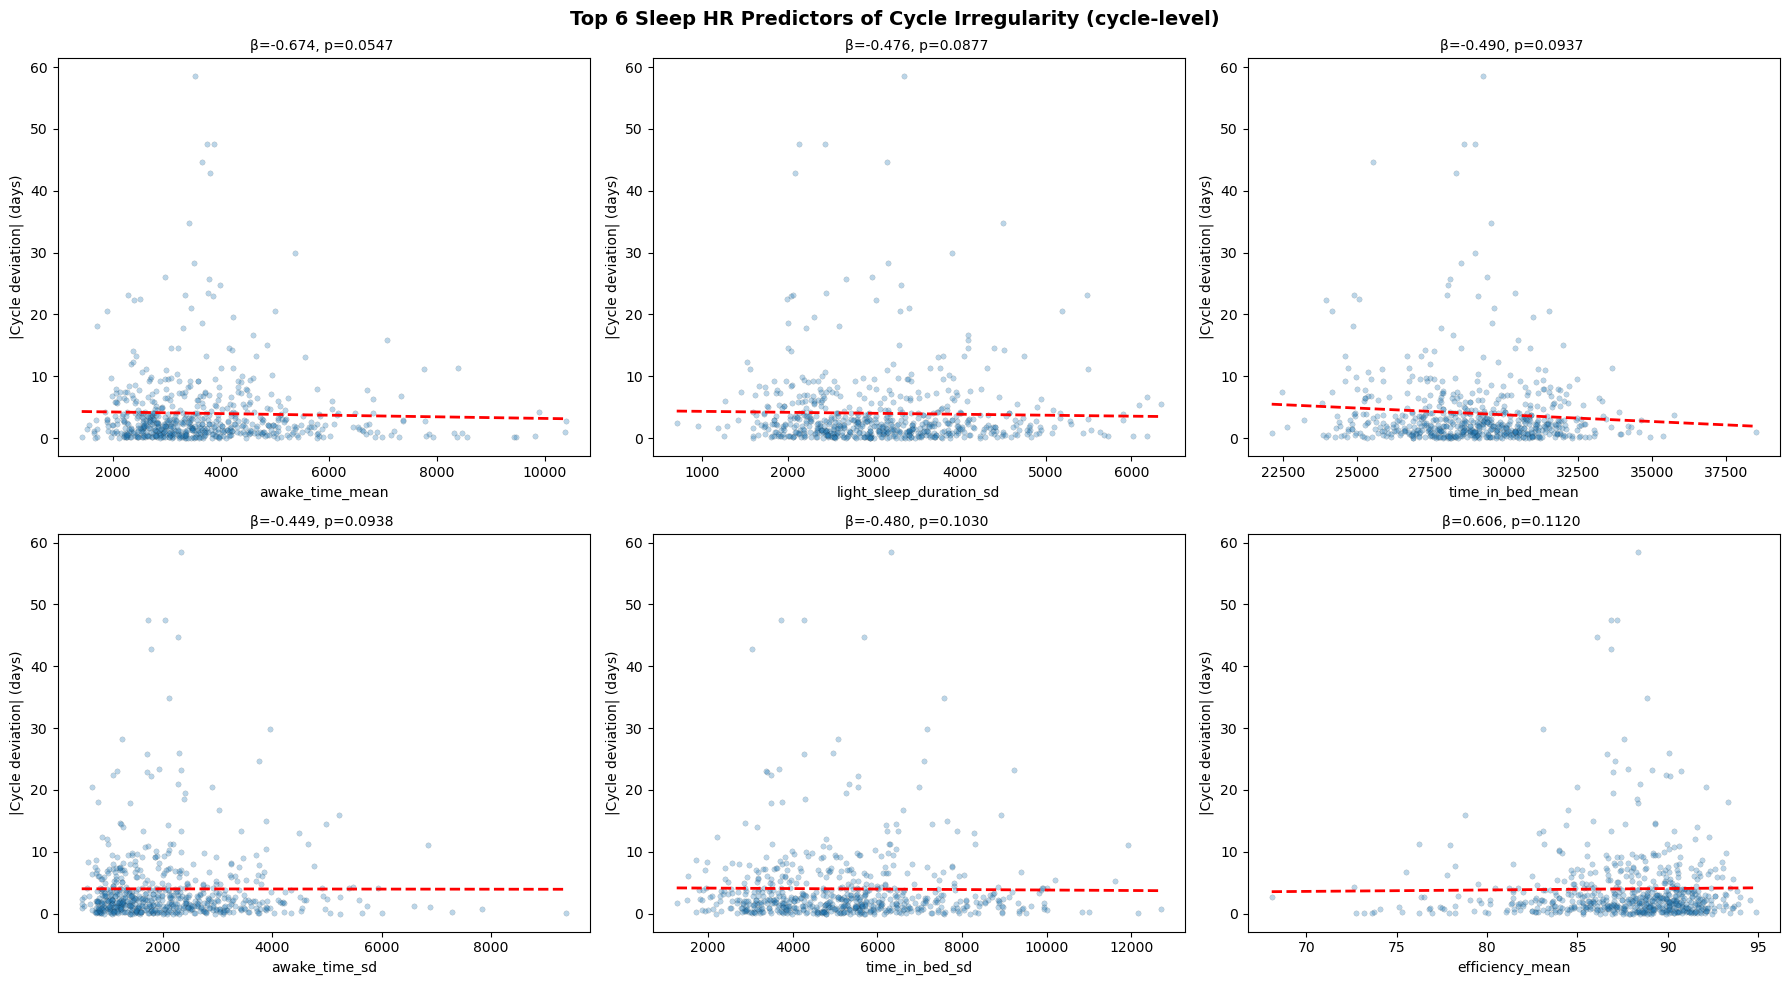

In [256]:
# Scatter plots for top 6 sleep_hr predictors (by p-value)
top_preds = hr_results_df.sort_values("abs_dev_p").head(6)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, (_, row) in enumerate(top_preds.iterrows()):
    pred = row["predictor"]
    ax = axes[idx]
    tmp = cycle_hr_lvl.dropna(subset=[pred, "abs_cycle_deviation"])

    ax.scatter(tmp[pred], tmp["abs_cycle_deviation"],
               alpha=0.3, edgecolors="k", linewidth=0.2, s=15)
    z = np.polyfit(tmp[pred], tmp["abs_cycle_deviation"], 1)
    x_line = np.linspace(tmp[pred].min(), tmp[pred].max(), 100)
    ax.plot(x_line, np.poly1d(z)(x_line), "r--", linewidth=2)
    ax.set_xlabel(pred)
    ax.set_ylabel("|Cycle deviation| (days)")
    sig = row["abs_dev_sig"]
    ax.set_title(f"β={row['abs_dev_beta']:.3f}, p={row['abs_dev_p']:.4f} {sig}", fontsize=10)

plt.suptitle("Top 6 Sleep HR Predictors of Cycle Irregularity (cycle-level)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "cycle_level_sleephr_top6.png", dpi=200, bbox_inches="tight")
plt.show()

In [257]:
# Prepare sleeprhr weekly data
sleeprhr_weekly = pd.read_csv(DOWNLOADS / "sleeprhr_weeklies_aug2024jan2026.csv")
sleeprhr_weekly[["week_start_str", "week_end_str"]] = sleeprhr_weekly["date_range"].str.split(" to ", expand=True)
sleeprhr_weekly["week_start"] = pd.to_datetime(sleeprhr_weekly["week_start_str"], errors="coerce")
sleeprhr_weekly["id_num"] = pd.to_numeric(sleeprhr_weekly["name"].astype(str).str.strip(), errors="coerce")
sleeprhr_weekly["within_four_hours_count"] = pd.to_numeric(sleeprhr_weekly["within_four_hours_count"], errors="coerce")

sleeprhr_weekly = sleeprhr_weekly[["id_num", "week_start", "within_four_hours_count"]].dropna()

print(f"Sleep regularity weekly rows: {len(sleeprhr_weekly)}")
print(f"Unique participants: {sleeprhr_weekly['id_num'].nunique()}")
sleeprhr_weekly.head()

Sleep regularity weekly rows: 4441
Unique participants: 81


,id_num,week_start,within_four_hours_count
0,10201.0,2024-09-15,3
1,10201.0,2024-09-22,4
2,10201.0,2024-09-29,1
3,10201.0,2024-10-06,4
4,10201.0,2024-10-13,3


In [258]:
# Match sleep regularity weeks to each cycle window
matched_rhr = []

for _, cyc in cycle_df.iterrows():
    pid = cyc["id_num"]
    c_start = cyc["menzie_start"]
    c_end = cyc["cycle_end"]

    mask = (
        (sleeprhr_weekly["id_num"] == pid) &
        (sleeprhr_weekly["week_start"] >= c_start) &
        (sleeprhr_weekly["week_start"] < c_end)
    )
    weeks = sleeprhr_weekly.loc[mask]

    if len(weeks) > 0:
        matched_rhr.append({
            "id_num": pid,
            "menzie_start": c_start,
            "cycle_end": c_end,
            "cycle_length_days": cyc["cycle_length_days"],
            "cycle_deviation": cyc["cycle_deviation"],
            "abs_cycle_deviation": cyc["abs_cycle_deviation"],
            "cycle_within4hr_mean": weeks["within_four_hours_count"].mean(),
            "n_rhr_weeks": len(weeks),
        })

cycle_rhr_lvl = pd.DataFrame(matched_rhr)
print(f"Cycles with matched sleep regularity data: {len(cycle_rhr_lvl)}")
print(f"Unique participants: {cycle_rhr_lvl['id_num'].nunique()}")
print(f"\nWeeks matched per cycle:")
print(cycle_rhr_lvl["n_rhr_weeks"].describe())

Cycles with matched sleep regularity data: 627
Unique participants: 76

Weeks matched per cycle:
count    627.000000
mean       4.200957
std        1.532752
min        1.000000
25%        4.000000
50%        4.000000
75%        5.000000
max       25.000000
Name: n_rhr_weeks, dtype: float64


In [259]:
# Mixed-effects models: sleep regularity during cycle
cycle_rhr_lvl = cycle_rhr_lvl.merge(covars[["id_num", "years", "bmi"]], on="id_num", how="left")
cycle_rhr_lvl = cycle_rhr_lvl.dropna(subset=["cycle_within4hr_mean", "abs_cycle_deviation", "years", "bmi"])

cycle_rhr_lvl["rhr_z"] = zscore(cycle_rhr_lvl["cycle_within4hr_mean"])
cycle_rhr_lvl["age_z"] = zscore(cycle_rhr_lvl["years"])
cycle_rhr_lvl["bmi_z"] = zscore(cycle_rhr_lvl["bmi"])

print(f"Final dataset: {len(cycle_rhr_lvl)} cycles from {cycle_rhr_lvl['id_num'].nunique()} participants\n")

# Model 1: Absolute deviation
model_rhr_abs = smf.mixedlm(
    "abs_cycle_deviation ~ rhr_z + age_z + bmi_z",
    data=cycle_rhr_lvl,
    groups=cycle_rhr_lvl["id_num"]
).fit()
print("=" * 70)
print("SLEEP REGULARITY MODEL 1: |Cycle deviation| ~ within_4hr during cycle")
print("=" * 70)
print(model_rhr_abs.summary())

# Model 2: Signed deviation
model_rhr_signed = smf.mixedlm(
    "cycle_deviation ~ rhr_z + age_z + bmi_z",
    data=cycle_rhr_lvl,
    groups=cycle_rhr_lvl["id_num"]
).fit()
print("\n" + "=" * 70)
print("SLEEP REGULARITY MODEL 2: Cycle deviation (signed) ~ within_4hr during cycle")
print("=" * 70)
print(model_rhr_signed.summary())

Final dataset: 625 cycles from 75 participants

SLEEP REGULARITY MODEL 1: |Cycle deviation| ~ within_4hr during cycle
              Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: abs_cycle_deviation
No. Observations: 625     Method:             REML               
No. Groups:       75      Scale:              19.8297            
Min. group size:  1       Log-Likelihood:     -1914.6907         
Max. group size:  19      Converged:          Yes                
Mean group size:  8.3                                            
-------------------------------------------------------------------
               Coef.    Std.Err.     z      P>|z|   [0.025   0.975]
-------------------------------------------------------------------
Intercept       4.851      0.723    6.706   0.000    3.433    6.269
rhr_z          -0.012      0.283   -0.042   0.967   -0.566    0.543
age_z           0.886      0.707    1.253   0.210   -0.500    2.272
bmi_z          -0.563     

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(



SLEEP REGULARITY MODEL 2: Cycle deviation (signed) ~ within_4hr during cycle
            Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: cycle_deviation
No. Observations: 625     Method:             REML           
No. Groups:       75      Scale:              54.1751        
Min. group size:  1       Log-Likelihood:     -2134.2515     
Max. group size:  19      Converged:          No             
Mean group size:  8.3                                        
--------------------------------------------------------------
               Coef.   Std.Err.    z     P>|z|  [0.025  0.975]
--------------------------------------------------------------
Intercept       0.046     0.298   0.154  0.877  -0.538   0.630
rhr_z           0.156     0.296   0.525  0.599  -0.425   0.737
age_z           0.010     0.300   0.034  0.973  -0.577   0.598
bmi_z          -0.005     0.300  -0.016  0.987  -0.592   0.583
Group Var       0.119                                      

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2206: ConvergenceWarning: MixedLM optimization failed, trying a different optimizer may help.
  warnings.warn(msg, ConvergenceWarning)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2218: ConvergenceWarning: Gradient optimization failed, |grad| = 26.548765
  warnings.warn(msg, ConvergenceWarning)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
